# Libs, data, functions

## Libraries

In [1]:
# !pip install mne
# !pip install spkit

In [2]:
# !pip install neurodsp

In [3]:
# NeuroDSP
from neurodsp.spectral import compute_spectrum, rotate_powerlaw
from neurodsp.utils import create_times
from neurodsp.utils.download import load_ndsp_data
from neurodsp.plts.spectral import plot_power_spectra
from neurodsp.plts.time_series import plot_time_series
# MNE
import mne.time_frequency
# Other
from scipy.io import loadmat
from mne.preprocessing import ICA, corrmap, create_ecg_epochs, create_eog_epochs
import spkit as sp
from spkit.data import load_data
import numpy as np
from sklearn.decomposition import PCA
import plotly
from scipy import signal
from scipy.signal import savgol_filter
from scipy.signal import iirdesign
from scipy.signal import butter, filtfilt
from scipy.signal import find_peaks
from scipy.stats import zscore
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.stats import mode
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from scipy.interpolate import interp1d
import mne
import math
import bisect
import h5py
from tqdm import tqdm
import os
import Artefacts_Detection as A

## Frequency bands

In [4]:
# Frequency bands
noise_band = [0,0.5]
delta_band = [0.5,5]
theta_band = [4,8]
sigma_band = [11,17]
beta_band = [22,30]
gamma_band = [35,45]
total_band = [0,30]
# noise_band = [0,0.49]
# delta_band = [0.5,3.99]
# theta_band = [4,7.99]
alpha_band = [8,12]
# sigma_band = [12,15.99]
# beta_band = [16,29.99]
# gamma_band = [30,40]
total_band = [0,30]



## Functions



In [6]:
# Using MNE's multitapering (~3-4min)

def psd_multitaper(lfp_data, fs, frequency_band):
    all_power_sum = []
    
    # loop through each segment
    for start in range(0, len(lfp_data) - window_length + 1, window_length):
        window = lfp_data[start:min(start + window_length, len(lfp_data))]

        # compute power spectral density using multitaper method
        psd, freqs = mne.time_frequency.psd_array_multitaper(window, fs, fmin=frequency_band[0], fmax=frequency_band[1], n_jobs=1, verbose = 'warning')

        # compute total power within frequency band
        freq_indices = (freqs >= frequency_band[0]) & (freqs <= frequency_band[1])
        curr_sum = np.sum(psd)
        all_power_sum.append(curr_sum)

    return all_power_sum

### Power ratios functions

In [7]:
def PRnoise(noise, total):
  prnoise = np.array([])
  for i in range(len(noise)):
    value = (noise[i])/total[i]
    prnoise = np.append(prnoise, [value])
  return prnoise

In [8]:
def PRdelta(delta, total):
  prdelta = np.array([])
  for i in range(len(delta)):
    value = (delta[i])/total[i]
    prdelta = np.append(prdelta, [value])
  return prdelta

In [9]:
def PRsigma(sigma, total):
  prsigma = np.array([])
  for i in range(len(sigma)):
    value = (sigma[i])/total[i]
    prsigma = np.append(prsigma, [value])
  return prsigma

### Wei indexes functions

In [10]:
def index_W(delta, gamma, EMG):
  index_w = np.array([])
  for i in range(len(delta)):
    value = (EMG[i]*gamma[i])/delta[i]
    index_w = np.append(index_w, [value])
  return index_w

In [11]:
def index_N(delta, sigma, gamma):
  index_n = np.array([])
  for i in range(len(delta)):
    value = (delta[i]*sigma[i])/(gamma[i]**2)
    index_n = np.append(index_n, [value])
  return index_n    

In [12]:
def index_R(delta, theta, sigma, EMG):
  index_r = np.array([])
  for i in range(len(delta)):
    value = (theta[i]**3)/(delta[i]*sigma[i]*EMG[i])
    index_r = np.append(index_r, [value])
  return index_r

In [13]:
def index_A(noise, delta, theta, sigma, beta, gamma):
  index_a = np.array([])
  for i in range(len(beta)):
    value = ((2*noise[i]+beta[i])*gamma[i])/(delta[i]+theta[i]+sigma[i]+beta[i]+gamma[i])
    index_a = np.append(index_a, [value])
  return index_a

In [14]:
def Artefact_index(index_A, index_N, index_R):
  artefact_index = np.array([])
  for i in range(len(index_A)):
    value = index_A[i]/(index_N[i]+index_R[i]+index_A[i])
    artefact_index = np.append(artefact_index, [value])
  return artefact_index

In [15]:
def Index_1(delta, gamma, EMG):
  index_1 = np.array([])
  for i in range(len(delta)):
    value = (EMG[i]*gamma[i])/(delta[i])
    index_1 = np.append(index_1, [value])
  return index_1

In [16]:
def Index_2(delta, theta, sigma):
  index_2 = np.array([])
  for i in range(len(delta)):
    value = (sigma[i]*delta[i])/(theta[i])
    index_2 = np.append(index_2, [value])
  return index_2

In [17]:
def Index_3(delta, theta, gamma):
  index_3 = np.array([])
  for i in range(len(delta)):
    value = (theta[i]*gamma[i])/(delta[i])
    index_3 = np.append(index_3, [value])
  return index_3

In [18]:
def Index_4(delta, theta):
  index_4 = np.array([])
  for i in range(len(delta)):
    value = delta[i]/theta[i]
    index_4 = np.append(index_4, [value])
  return index_4

### New indices functions

In [19]:
def nindex_W(theta, gamma, EMG):
  index_w = np.array([])
  for i in range(len(theta)):
    value = EMG[i]*EMG[i]*((gamma[i])/(theta[i]))
    index_w = np.append(index_w, [value])
  return index_w

def nindex_R(delta, theta, sigma, EMG, gamma):
  nindex_r = np.array([])
  for i in range(len(delta)):
    value = ((theta[i]*2)*gamma[i])/(delta[i]*delta[i]*EMG[i]**2)
    nindex_r = np.append(nindex_r, [value])
  return nindex_r

def nindex_N(delta, sigma, gamma):
  nindex_n = np.array([])
  for i in range(len(delta)):
    value = (delta[i]*sigma[i]*sigma[i]/(EMG_norm[i]*theta[i]*gamma[i]**2))
    nindex_n = np.append(nindex_n, [value])
  return nindex_n

def nindex_N2(delta, theta, sigma, EMG, gamma):
  nindex_n = np.array([])
  for i in range(len(delta)):
    value = (delta[i]*sigma[i]*sigma[i]/(EMG[i]*gamma[i]**2))
    nindex_n = np.append(nindex_n, [value])
  return nindex_n

def nindex_N3(delta, theta, sigma, EMG, gamma):
  nindex_n = np.array([])
  for i in range(len(delta)):
    value = ((sigma[i])/(gamma[i]*EMG[i]*gamma[i]*theta[i]))
    nindex_n = np.append(nindex_n, [value])
  return nindex_n

### Wei normalisation

In [20]:
def wei_normalizing(data):
    data = np.array(data)

    bottom = data[data <= np.nanpercentile(data, 10, axis=0)]
    top = data[data >= np.nanpercentile(data, 90, axis=0)]

    bottom_avg = np.average(bottom) if len(bottom) > 0 else 0
    top_avg = np.average(top) if len(top) > 0 else 1

    denom = top_avg - bottom_avg if top_avg != bottom_avg else 1
    normalized_data = (data - bottom_avg) / denom
    normalized_data = np.clip(normalized_data, 0.05, 1)

    return normalized_data

###  Get matrix of new features

In [21]:
def getNewFeatures(raw_hpc, raw_pfc):

  # Getting EMG
  emg_sampling = 5
  smoothWindow = fs
  EMGFromLFP = compute_emg_buzsakiMethod(emg_sampling,fs,raw_pfc,raw_hpc,smoothWindow,'emglikesignal')
  EMG = EMGFromLFP['data']
  emg_mat_norm = EMGFromLFP['Norm']
  emg_mat_smoothed = EMGFromLFP['smoothed']
  if len(EMG) % 2 == 1:
    EMG = np.append(EMG, EMG[-1])
  EMG =EMG[:len(EMG) // (epoch_length*emg_sampling) * (epoch_length*emg_sampling)]
  EMG = EMG.reshape(-1, (epoch_length*emg_sampling))
  EMG = EMG.sum(axis=1)

  # Get mapped scores
  sleep_scoring = np.ravel(states)
  reshaped_scores = sleep_scoring[:len(sleep_scoring) // epoch_length * epoch_length].reshape(-1, epoch_length)
  majority_scores = mode(reshaped_scores, axis=1).mode.flatten()
  score_labels = {0: 'Unknown', 1: 'Wake', 3: 'NREM', 4: 'Intermediate', 5: 'REM'}
  majority_states = [score_labels[state] for state in majority_scores]
  mapped_scores = np.array(majority_states)
  sleep_time_minutes = np.arange(0, len(majority_scores)) * epoch_length / 60
  num_labels = {label: num for num, label in enumerate(score_labels.values(), start=1)}

  # Get powers
  noise = psd_multitaper(np.ravel(raw_hpc), fs, noise_band)
  delta = psd_multitaper(np.ravel(raw_pfc), fs, delta_band)
  theta = psd_multitaper(np.ravel(raw_hpc), fs, theta_band)
  sigma = psd_multitaper(np.ravel(raw_pfc), fs, sigma_band)
  gamma = psd_multitaper(np.ravel(raw_pfc), fs, gamma_band)

  # Normalize all these powers
  noise_norm = wei_normalizing(noise)
  delta_norm = wei_normalizing(delta)
  theta_norm = wei_normalizing(theta)
  sigma_norm = wei_normalizing(sigma)
  gamma_norm = wei_normalizing(gamma)
  EMG_norm = wei_normalizing(EMG)

  # Get smoothed powers as feature
  noise_smoothed = np.convolve(np.convolve(np.convolve(noise_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
  theta_smoothed = np.convolve(np.convolve(np.convolve(theta_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
  delta_smoothed = np.convolve(np.convolve(np.convolve(delta_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')

  # Compute new indices
  nindex_w = nindex_W(theta_norm, gamma_norm, EMG_norm)
  nindex_n = nindex_N(delta_norm, sigma_norm, gamma_norm)
  nindex_r = nindex_R(delta_norm, theta_norm, sigma_norm, EMG_norm, gamma_norm)
  index_1 = Index_1(delta_norm, gamma_norm, EMG_norm)
  index_2 = Index_2(delta_norm, theta_norm, sigma_norm)
  index_3 = Index_3(delta_norm, theta_norm, gamma_norm)
  index_4 = Index_4(delta_norm, theta_norm)

  # Take log of indices
  nindex_w_log = np.log(nindex_w)
  nindex_n_log = np.log(nindex_n)
  nindex_r_log = np.log(nindex_r)
  index_1_log = np.log(index_1)
  index_2_log = np.log(index_2)
  index_3_log = np.log(index_3)
  index_4_log = np.log(index_4)

  # Normalise indices
  nindex_w_norm = wei_normalizing(nindex_w_log)
  nindex_n_norm = wei_normalizing(nindex_n_log)
  nindex_r_norm = wei_normalizing(nindex_r_log)
  index_1_norm = wei_normalizing(index_1_log)
  index_2_norm = wei_normalizing(index_2_log)
  index_3_norm = wei_normalizing(index_3_log)
  index_4_norm = wei_normalizing(index_4_log)

  # Smooth indices
  nindex_w_smoothed = np.convolve(np.convolve(np.convolve(nindex_w_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
  nindex_n_smoothed = np.convolve(np.convolve(np.convolve(nindex_n_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
  nindex_r_smoothed = np.convolve(np.convolve(np.convolve(nindex_r_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
  index_1_smoothed = np.convolve(np.convolve(np.convolve(index_1_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
  index_2_smoothed = np.convolve(np.convolve(np.convolve(index_2_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
  index_3_smoothed = np.convolve(np.convolve(np.convolve(index_3_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
  index_4_smoothed = np.convolve(np.convolve(np.convolve(index_4_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')


  # Create matrix
  new_features = np.column_stack((nindex_w_smoothed, nindex_r_smoothed, nindex_n_smoothed, index_1_smoothed, index_2_smoothed, index_3_smoothed, index_4_smoothed, noise_smoothed, theta_smoothed, delta_smoothed))
  np.save('new_features.npy', new_features)

  return new_features, mapped_scores

### Plot results of new features

In [22]:
def plots(new_features, mapped_scores):

  epochs = np.arange(len(mapped_scores))
  fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize = (28, 8))
  # Plot data on each subplot
  ax1.plot(epochs, new_features[:,0], label='Index W', color='black')
  ax1.plot(epochs, new_features[:,2], label='Index N', color='blue')
  ax1.plot(epochs, new_features[:,1], label='Index R', color='red')

  ax1.plot(epochs, new_features[:,0], label='Index W', color='black')
  ax1.plot(epochs, new_features[:,2], label='Index N', color='blue')
  ax1.plot(epochs, new_features[:,1], label='Index R', color='red')

  ax2.plot(epochs, mapped_scores, label='Mapped scores')

  # Add legends
  ax1.legend()
  ax2.legend()
  # Add titles
  ax1.set_title('New indices')
  ax2.set_title('Mapped scores')
  # Adjust layout to avoid overlap
  plt.tight_layout()
  # Show the plots
  plt.show()


  # Barplot
  index_Wake = [[],[],[]]
  index_NREM = [[],[],[]]
  index_REM = [[],[],[]]
  for i, el in enumerate(mapped_scores):

    if el == 'Wake':
      index_Wake[0].append(new_features[:,0][i])
      index_Wake[1].append(new_features[:,1][i])
      index_Wake[2].append(new_features[:,2][i])
    elif el == 'NREM':
      index_NREM[0].append(new_features[:,0][i])
      index_NREM[1].append(new_features[:,1][i])
      index_NREM[2].append(new_features[:,2][i])
    elif el == 'REM':
      index_REM[0].append(new_features[:,0][i])
      index_REM[1].append(new_features[:,1][i])
      index_REM[2].append(new_features[:,2][i])

  wake_w = np.average(index_Wake[0])
  wake_r = np.average(index_Wake[1])
  wake_n = np.average(index_Wake[2])
  NREM_w = np.average(index_NREM[0])
  NREM_r = np.average(index_NREM[1])
  NREM_n = np.average(index_NREM[2])
  REM_w = np.average(index_REM[0])
  REM_r = np.average(index_REM[1])
  REM_n = np.average(index_REM[2])

  if 'Wake' not in mapped_scores:
    nwake_w = 0
    nwake_r = 0
    nwake_n = 0
  if 'REM' not in mapped_scores:
    nREM_w = 0
    nREM_r = 0
    nREM_n = 0
  if 'NREM' not in mapped_scores:
    nNREM_w = 0
    nNREM_r = 0
    nNREM_n = 0

  plt.figure(figsize=(12, 6))
  # Wei indexes
  plt.subplot(1, 2, 1)
  categories = ['Wake', 'NREM', 'REM']
  index_types = ['Index_w', 'Index_r', 'Index_n']
  values_wake = [wake_w, NREM_w, REM_w]
  values_REM = [wake_r, NREM_r, REM_r]
  values_NREM = [wake_n, NREM_n, REM_n]
  x = np.arange(len(categories))
  bar_width = 0.2
  # Create bar plots
  plt.bar(x - bar_width, values_wake, width=bar_width, label='Index W', color = 'black')
  plt.bar(x, values_REM, width=bar_width, label='Index R', color = 'red',)
  plt.bar(x + bar_width, values_NREM, width=bar_width, label='Index N', color = 'blue')
  # Add labels and title
  plt.xlabel('Sleep Stages')
  plt.ylabel('Average Index Values')
  plt.title('New indexes')
  plt.xticks(x, categories)
  plt.legend()

  for i in range(len(categories)):
    plt.text(x[i] - bar_width, values_wake[i] + 0.02, str(round(values_wake[i], 2)), ha='center', va='bottom')
    plt.text(x[i], values_REM[i] + 0.02, str(round(values_REM[i], 2)), ha='center', va='bottom')
    plt.text(x[i] + bar_width, values_NREM[i] + 0.02, str(round(values_NREM[i], 2)), ha='center', va='bottom')

In [23]:
def spike_conflict_avg(arraya, arrayb):
    avg = (arraya + arrayb) / 2
    agreement = 1- np.abs(arraya - arrayb)
    result = avg + (arraya * arrayb - (1 - arraya) * (1-arrayb)) * (agreement - 0.5)
    result = np.clip(result, 0, 1)
    return result

In [24]:
def cross_correlation(EOG1, EOG2, epoch_length, fs, lag=0):
    samples = int(epoch_length * fs)
    cross_cor_epochs = []

    for i in range(0, len(EOG1) - len(EOG1) % samples, samples):
        epoch1 = EOG1[i:i + samples]
        epoch2 = EOG2[i:i + samples]
        cc_full = np.correlate(epoch1, epoch2, mode='full')
        center = len(cc_full) // 2
        cross_cor_epochs.append(cc_full[center + lag])

    return cross_cor_epochs
def auto_correlation_slope(EOG, epoch_length, fs):
    samples = int(epoch_length * fs)
    slopes = []

    for i in range(0, len(EOG) - len(EOG) % samples, samples):
        epoch = EOG[i:i + samples]
        ac = np.correlate(epoch, epoch, mode='full')
        center = len(ac) // 2
        ac = ac[center:]
        peaks, _ = find_peaks(ac)
        if len(peaks) < 1:
            slopes.append(0)
            continue
        first_peak_idx = peaks[0]
        slope = (ac[first_peak_idx] - ac[0]) / first_peak_idx
        slopes.append(slope)

    return slopes
def auto_correlation(EOG, epoch_length, fs):
    samples = int(epoch_length * fs)
    auto_corr = np.array([])
    for i in range(0, len(EOG) - len(EOG) % samples, samples):
        epoch = EOG[i:i + samples]
        squared = np.sum(epoch*epoch)
        auto_corr = np.append(auto_corr, squared)
    return(auto_corr)
def rem_feature(EOG1, EOG2, epoch_length, fs):
    rem_features = np.array([])
    b, a = butter(4, [0.3 / (0.5 * fs), 35 / (0.5 * fs)], btype='band')
    EOG1 = filtfilt(b, a, EOG1)
    EOG2 = filtfilt(b, a, EOG2)
    cross_cor_val = cross_correlation(EOG1, EOG2, epoch_length, fs, 0)
    auto_slope = auto_correlation_slope(EOG1, epoch_length, fs)
    for count, slope in enumerate(auto_slope):
        eog_feature = (1/slope)*np.sign(cross_cor_val[count])
        rem_features = np.append(rem_features, eog_feature)
    return rem_features

# Test on a post trial

See how spectral powers for different frequency bands evolve with sleep and how they correlate with sleep states in the manual scoring.
Get plots of the features' evolution over time, compared to manual hypnogram. Compare Wei features to our features.

## Loading Data

In [25]:
fs = 250  # EEG sampling frequency
window_length = 10 * fs
epoch_length = int(window_length / fs)

In [26]:
files = [
    "C:/EEG_Data_stage/2/iEEG/converted_intra/2_night1_01.vhdr",
    "C:/EEG_Data_stage/2/iEEG/converted_intra/2_night1_02.vhdr",
    "C:/EEG_Data_stage/2/iEEG/converted_intra/2_night1_03.vhdr"
]

raw_list = [mne.io.read_raw_brainvision(f, preload=True) for f in files]
raw = mne.concatenate_raws(raw_list)
raw.filter(l_freq=10, h_freq=70, picks='EMG1-EMG2')
hpc_data = raw.get_data(picks='TR10-Cz')[0]
hpc_tag = 'TR10'
raw_hpc = np.ravel(hpc_data)

Extracting parameters from C:/EEG_Data_stage/2/iEEG/converted_intra/2_night1_01.vhdr...
Setting channel info structure...
Reading 0 ... 3596783  =      0.000 ... 14387.132 secs...
Extracting parameters from C:/EEG_Data_stage/2/iEEG/converted_intra/2_night1_02.vhdr...
Setting channel info structure...
Reading 0 ... 3599951  =      0.000 ... 14399.804 secs...
Extracting parameters from C:/EEG_Data_stage/2/iEEG/converted_intra/2_night1_03.vhdr...
Setting channel info structure...
Reading 0 ... 3599871  =      0.000 ... 14399.484 secs...
Filtering a subset of channels. The highpass and lowpass values in the measurement info will not be updated.
Filtering raw data in 3 contiguous segments
Setting up band-pass filter from 10 - 70 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 10.00
- Low

In [27]:
pfc_data = raw.get_data(picks='TL01-Cz')[0]
pfc_tag = 'TL01'
raw_pfc = np.ravel(pfc_data)

In [28]:
# states = np.load("D:/converted_sleep_data/2/combined_nights/edf_files/night2_hypnogram_30s.npy")
scores_files = [
    "C:/EEG_Data_stage/2/iEEG/edf/2_night1_01_hypnogram.npy",
    "C:/EEG_Data_stage/2/iEEG/edf/2_night1_02_hypnogram.npy",
    "C:/EEG_Data_stage/2/iEEG/edf/2_night1_03_hypnogram.npy"
]

score_list = [np.load(f) for f in scores_files]
states = np.concatenate(score_list)
# states = np.append(states, [0,0,0])
print(f"Raw length: {len(raw_hpc)}")
print(f"Raw length / 250: {len(raw_hpc) / 250}")
print(f"Raw time in hours: {len(raw_hpc) / 250 / 3600}")
print(f"Raw epoch count: {len(raw_hpc) / 250 / 10}")
print(f"Sleep state amount: {len(states)}")

Raw length: 10796608
Raw length / 250: 43186.432
Raw time in hours: 11.996231111111111
Raw epoch count: 4318.6432
Sleep state amount: 4317


In [29]:
len(hpc_data)/(len(np.ravel(states)))

2500.9515867500577

In [30]:
len(states)*2

8634

## Get powers and plots


### Get EMG

In [31]:
from scipy.signal import hilbert
EMG = raw.get_data(picks='EMG1-EMG2')[0]
EMG = EMG[:len(EMG)// (epoch_length * fs) * (epoch_length * fs)] 
EMG = EMG.reshape(-1, (epoch_length * fs))
EMG = EMG.sum(axis=1)
# EMG = np.abs(EMG)
EMG = abs(hilbert(EMG))

In [32]:
amp_thresh = [10,5]         # 6σ for amplitude, 4σ for derivative
time_win_thresh = [0.2,0.1]
raw_hpc, inds, timeval = A.removeArtefacts(raw_hpc, 250, amp_thresh, time_win_thresh)
indices = A.artefact_epochs(inds, window_length)

In [33]:
raw_pfc, inds, timeval = A.removeArtefacts(raw_pfc, 250, amp_thresh, time_win_thresh)
indices = A.artefact_epochs(inds, window_length)

In [34]:
# EMG, inds, timeval = A.removeArtefacts(EMG, 250, amp_thresh, time_win_thresh)
# indices = A.artefact_epochs(inds, window_length)

### Get mapped scores

In [35]:
sleep_scoring = np.ravel(states)
# reshaped_scores = sleep_scoring[:len(sleep_scoring) // epoch_length * epoch_length].reshape(-1, epoch_length)
# majority_scores = mode(sleep_scor, axis=1).mode.flatten()
score_labels = {0: 'Wake', 1: 'N1', 2:'N2', 3: 'N3', 4: 'REM'}
# majority_states = [score_labels[state] for state in sleep_scoring]
mapped_scores = np.array(sleep_scoring)
sleep_time_minutes = np.arange(0, len(sleep_scoring)) * epoch_length / 60
num_labels = {label: num for num, label in enumerate(score_labels.values(), start=1)}

In [36]:
### Get EOG
# EOG1, EOG2 = np.ravel(raw.get_data(picks='EOG1')[0]), np.ravel(raw.get_data(picks='EOG2')[0])


In [37]:
epochs = np.arange(len(mapped_scores))
hypno_epochs = epochs
print(epochs)

[   0    1    2 ... 4314 4315 4316]


### Get powers


In [38]:
from joblib import Parallel, delayed
raws = [np.ravel(raw_pfc), np.ravel(raw_pfc), np.ravel(raw_hpc), np.ravel(raw_pfc), np.ravel(raw_pfc), np.ravel(raw_pfc), np.ravel(raw_hpc)]
fr_bands = [noise_band, delta_band, theta_band, sigma_band, beta_band, gamma_band, alpha_band]
noise, delta, theta, sigma, beta, gamma, alpha = Parallel(n_jobs=7)(delayed(psd_multitaper)(raw, fs, band) for raw, band in zip(raws, fr_bands))

In [39]:
noise_norm = wei_normalizing(noise)
delta_norm = wei_normalizing(delta)
theta_norm = wei_normalizing(theta)
sigma_norm = wei_normalizing(sigma)
beta_norm = wei_normalizing(beta)
gamma_norm = wei_normalizing(gamma)
alpha_norm = wei_normalizing(alpha)
#total_norm = wei_normalizing(total)
EMG_norm = wei_normalizing(EMG)
noise_smoothed = np.convolve(np.convolve(np.convolve(noise_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
theta_smoothed = np.convolve(np.convolve(np.convolve(theta_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
delta_smoothed = np.convolve(np.convolve(np.convolve(delta_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
alpha_smoothed = np.convolve(np.convolve(np.convolve(alpha_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
beta_smoothed = np.convolve(np.convolve(np.convolve(beta_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
sigma_smoothed = np.convolve(np.convolve(np.convolve(sigma_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
gamma_smoothed = np.convolve(np.convolve(np.convolve(gamma_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
EMG = np.convolve(EMG, np.ones(20*fs)/(20*fs), mode='same')

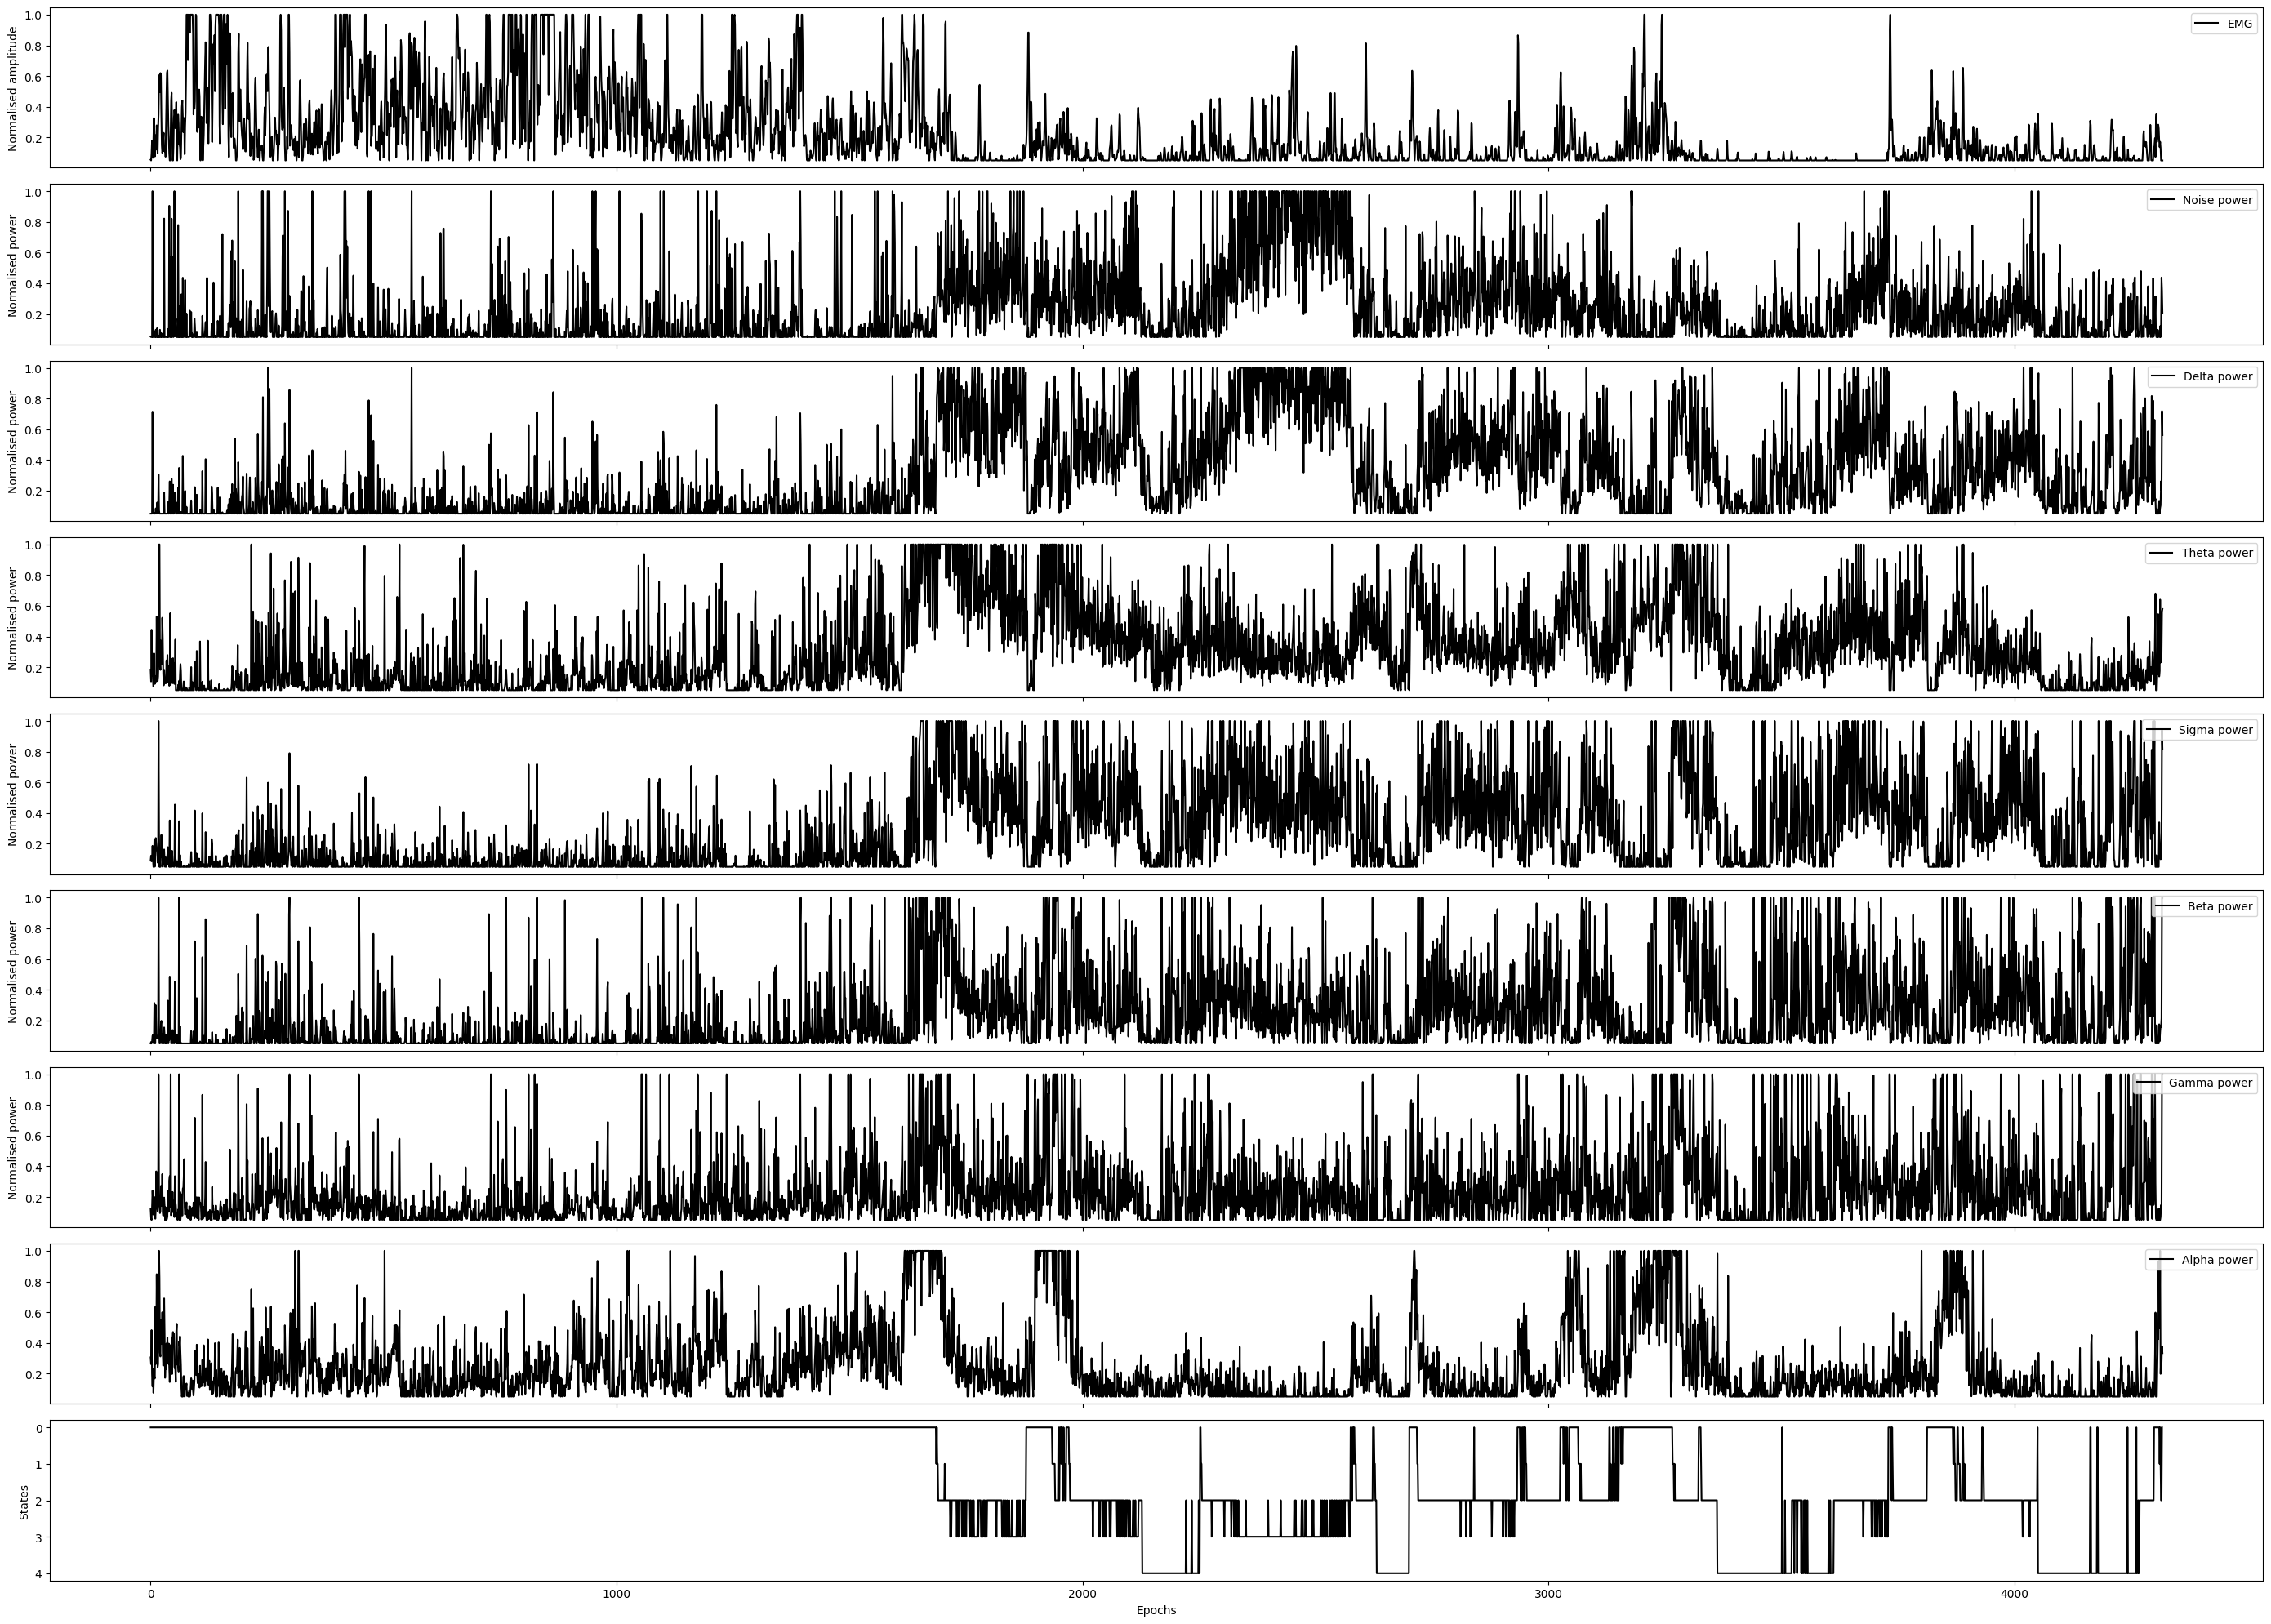

In [40]:
fig, (ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9) = plt.subplots(9, 1, sharex=True, figsize = (28, 20))
epochs = np.arange(len(EMG_norm))
# Plot data on each subplot
ax1.plot(epochs, EMG_norm, label='EMG', color = 'black')
ax2.plot(epochs, noise_norm, label='Noise power', color = 'black')
ax3.plot(epochs, delta_norm, label='Delta power', color = 'black')
ax4.plot(epochs, theta_norm, label='Theta power', color = 'black')
ax5.plot(epochs, sigma_norm, label='Sigma power', color = 'black')
ax6.plot(epochs, beta_norm, label='Beta power', color = 'black')
ax7.plot(epochs, gamma_norm, label='Gamma power', color = 'black')
ax8.plot(epochs, alpha_norm, label='Alpha power', color = 'black')
ax9.plot(hypno_epochs, sleep_scoring, label='Mapped scores', color = 'black')


ax1.legend(loc='upper right')
ax2.legend(loc='upper right')
ax3.legend(loc='upper right')
ax4.legend(loc='upper right')
ax5.legend(loc='upper right')
ax6.legend(loc='upper right')
ax7.legend(loc='upper right')
ax8.legend(loc='upper right')

ax1.set_ylabel('Normalised amplitude')
ax2.set_ylabel('Normalised power')
ax3.set_ylabel('Normalised power')
ax4.set_ylabel('Normalised power')
ax5.set_ylabel('Normalised power')
ax6.set_ylabel('Normalised power')
ax7.set_ylabel('Normalised power')
ax9.set_ylabel('States')
# ax8.set_yticks([0, 1, 2, 3, 4])
# ax8.set_yticklabels(state_labels)
ax9.invert_yaxis() 
ax9.set_xlabel('Epochs')
# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig("Normalised_powers.svg", format='svg', dpi=300)
# Show the plots
plt.show()

### Plots

C:\Users\timmi\AppData\Local\Temp\ipykernel_13172\992797199.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


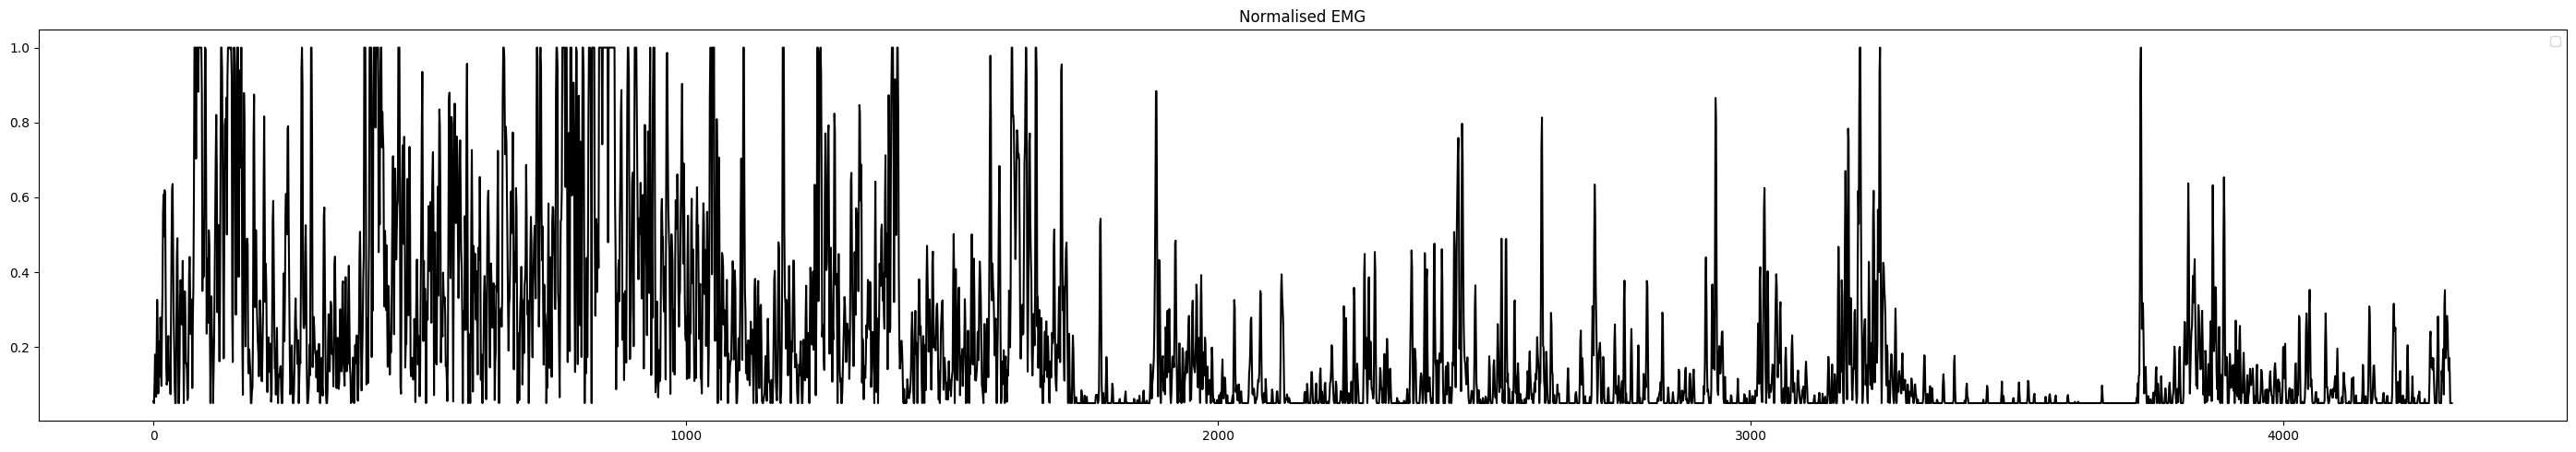

In [41]:

fig, (ax1) = plt.subplots(1, 1, sharex=True, figsize = (28, 5))

# Plot data on each subplot
ax1.plot(epochs, EMG_norm, label='', color = 'black')

# Add legends
ax1.legend()
ax1.set_title('Normalised EMG')
# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig("Normalised_EMG.svg", format='svg', dpi=300)
# Show the plots
plt.show()

C:\Users\timmi\AppData\Local\Temp\ipykernel_13172\3060580458.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


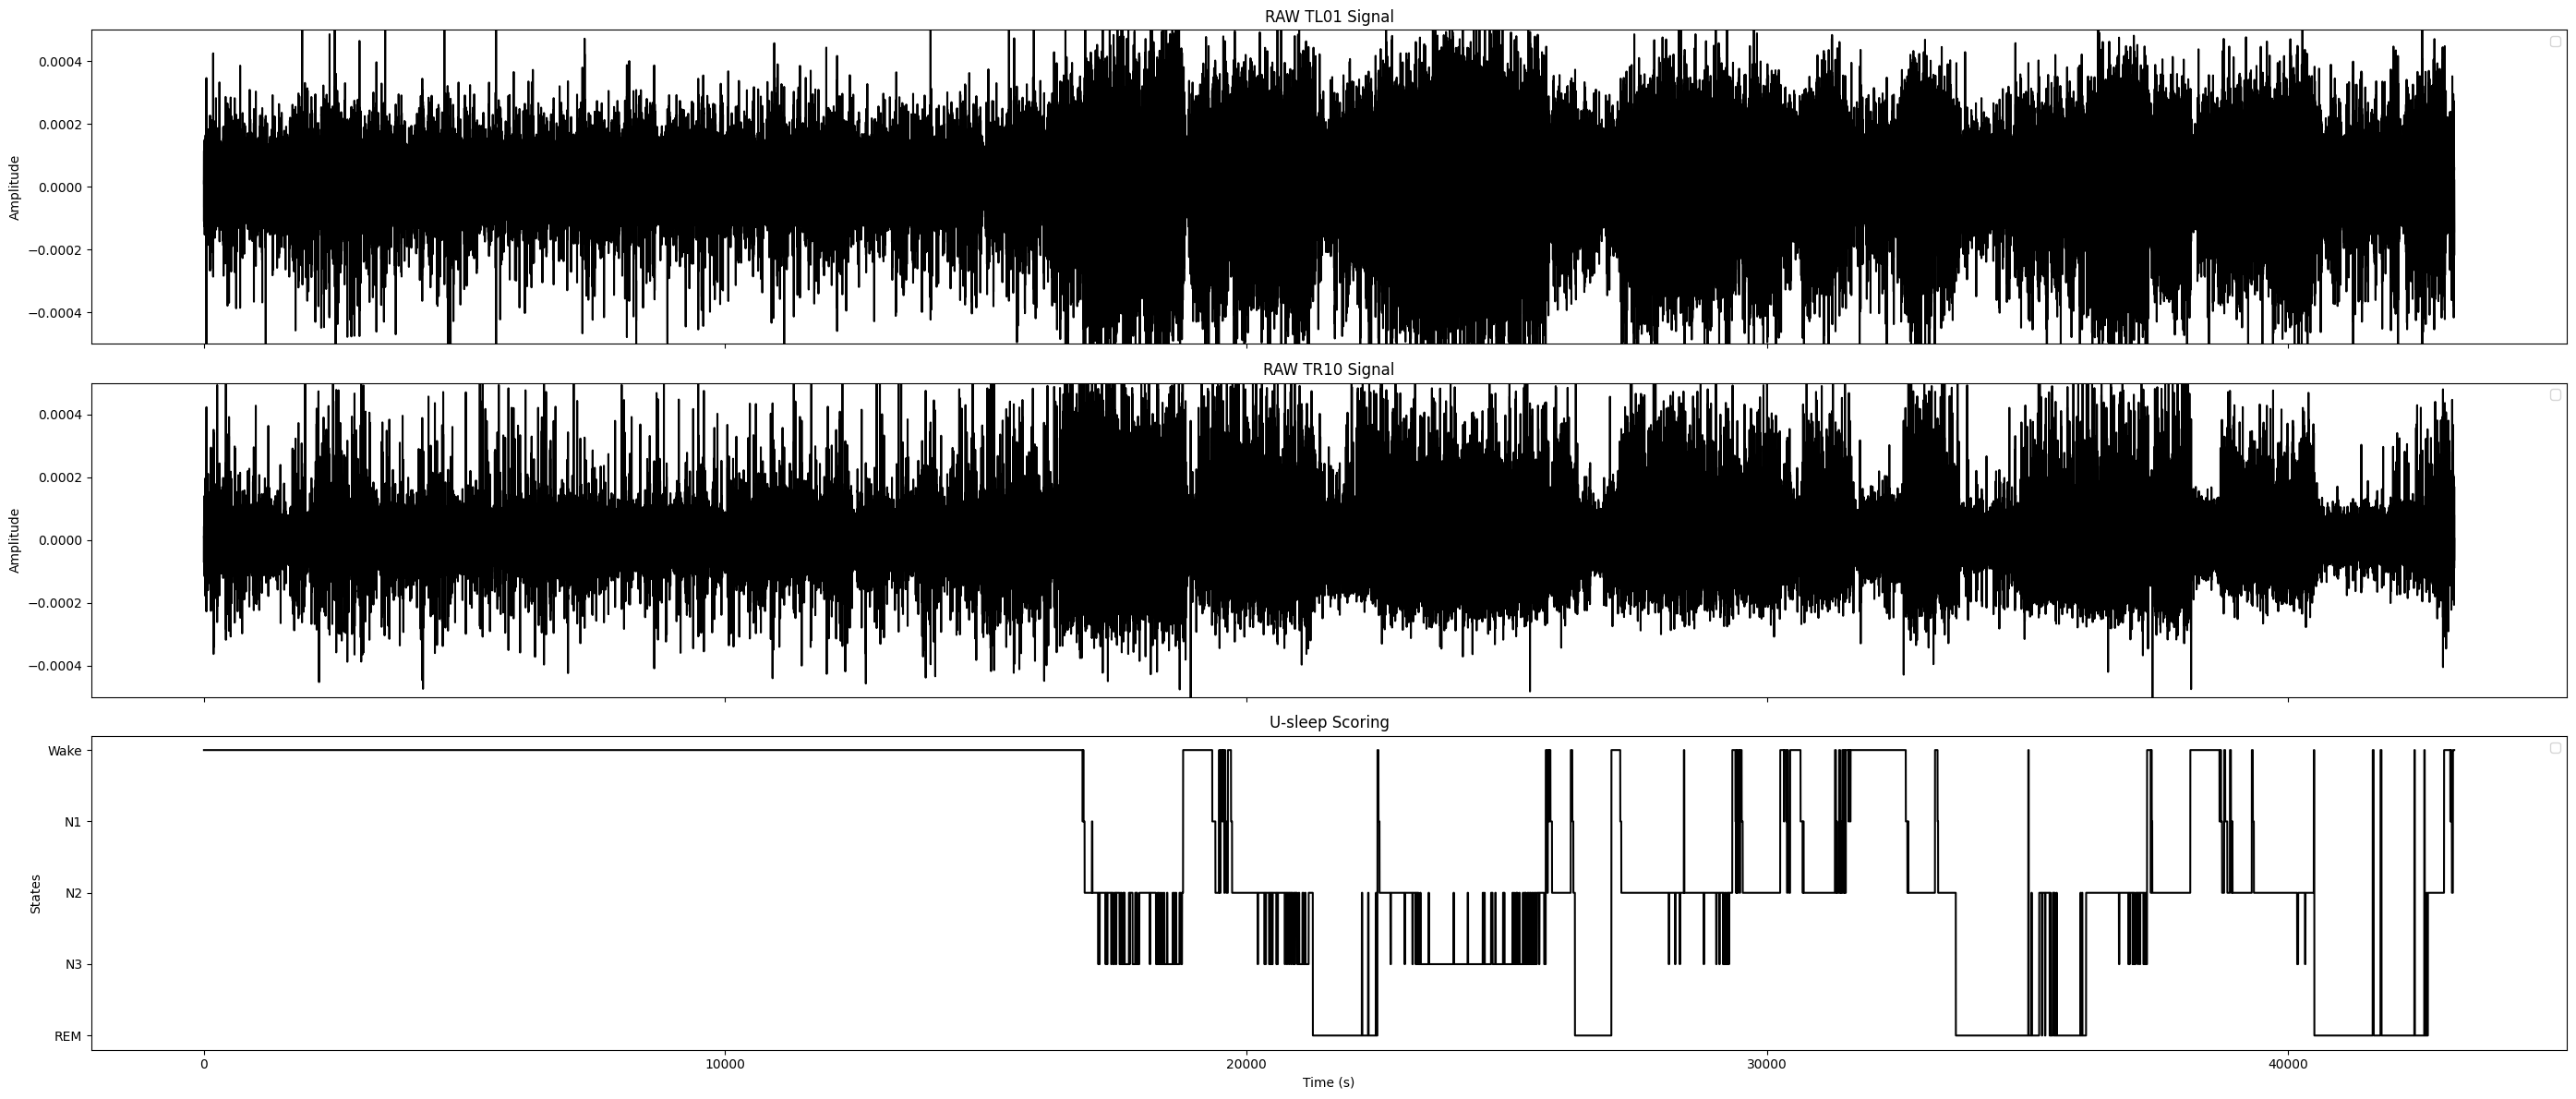

In [42]:
upsampled_states = np.repeat(states, 250 * 10)

target_len = len(raw_hpc)

if len(upsampled_states) < target_len:
    # pad with zeros
    pad_len = target_len - len(upsampled_states)
    upsampled_states = np.concatenate((upsampled_states, np.zeros(pad_len)))
elif len(upsampled_states) > target_len:
    # trim to match
    upsampled_states = upsampled_states[:target_len]
x = np.arange(len(raw_hpc))/250

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize=(28, 12))

# Plot data on each subplot
ax1.plot(x, raw_pfc, label='', color='black')
ax2.plot(x, raw_hpc, label='', color='black')
ax3.plot(x, upsampled_states, label='', color='black')

# Add legends
ax1.legend()
ax2.legend()
ax3.legend()

# Add axis titles
ax1.set_title(f'RAW {pfc_tag} Signal')
ax2.set_title(f'RAW {hpc_tag} Signal')
ax3.set_title('U-sleep Scoring')

ax1.set_ylabel('Amplitude')
ax2.set_ylabel('Amplitude')
ax3.set_ylabel('States')
ax3.set_xlabel('Time (s)')
state_labels = ['Wake', 'N1', 'N2', 'N3', 'REM']
ax3.set_yticks([0, 1, 2, 3, 4])
ax3.set_yticklabels(state_labels)
ax3.invert_yaxis() 
# Set y-axis limits (example values, adjust as needed)
ax1.set_ylim(-0.0005, 0.0005)  # Replace with appropriate limits for your data
ax2.set_ylim(-0.0005, 0.0005)  # Replace with appropriate limits for your data

# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig("RAW_signals_Hypnogram.svg", format='svg', dpi=300)
# Show the plots
plt.show()

## Indices

### Wei indexes

#### Get indices

In [43]:
# Raw indices

# rem_features = abs(rem_feature(EOG1, EOG2, epoch_length, fs))
# rem_features = wei_normalizing(rem_features)
# rem_features = np.convolve(np.convolve(np.convolve(rem_features, np.ones(5)/5, mode='same'), np.ones(5)/5,
#                                        mode='same'), np.ones(5)/5, mode='same')
index_w = index_W(delta_norm, gamma_norm, EMG_norm)
index_n = index_N(delta_norm, sigma_norm, gamma_norm)
index_r = index_R(delta_norm, theta_norm, sigma_norm, EMG_norm)
index_1 = Index_1(delta_norm, gamma_norm, EMG_norm)
index_2 = Index_2(delta_norm, theta_norm, sigma_norm)
index_3 = Index_3(delta_norm, theta_norm, gamma_norm)
index_4 = Index_4(delta_norm, theta_norm)

# Taking the log of the indices

index_w_log = np.log(index_w)
index_n_log = np.log(index_n)
index_r_log = np.log(index_r)
index_1_log = np.log(index_1)
index_2_log = np.log(index_2)
index_3_log = np.log(index_3)
index_4_log = np.log(index_4)

# Normalizing the indices

index_w_norm = wei_normalizing(index_w_log)
index_n_norm = wei_normalizing(index_n_log)
index_r_norm = wei_normalizing(index_r_log)
index_1_norm = wei_normalizing(index_1_log)
index_2_norm = wei_normalizing(index_2_log)
index_3_norm = wei_normalizing(index_3_log)
index_4_norm = wei_normalizing(index_4_log)

# Smoothing the indices

index_w_smoothed = np.convolve(np.convolve(np.convolve(index_w_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
index_n_smoothed = np.convolve(np.convolve(np.convolve(index_n_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
index_r_smoothed = np.convolve(np.convolve(np.convolve(index_r_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
index_1_smoothed = np.convolve(np.convolve(np.convolve(index_1_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
index_2_smoothed = np.convolve(np.convolve(np.convolve(index_2_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
index_3_smoothed = np.convolve(np.convolve(np.convolve(index_3_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
index_4_smoothed = np.convolve(np.convolve(np.convolve(index_4_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')



#### Save wei features matrix

In [44]:
wei_features = np.column_stack((index_w_smoothed, index_n_smoothed, index_r_smoothed, index_1_smoothed, index_2_smoothed, index_3_smoothed, index_4_smoothed, noise_smoothed, theta_smoothed, delta_smoothed))
#np.save('Wei_features.npy', wei_features)

In [45]:
print(mapped_scores)

[0 0 0 ... 2 2 0]


#### Main indices plots

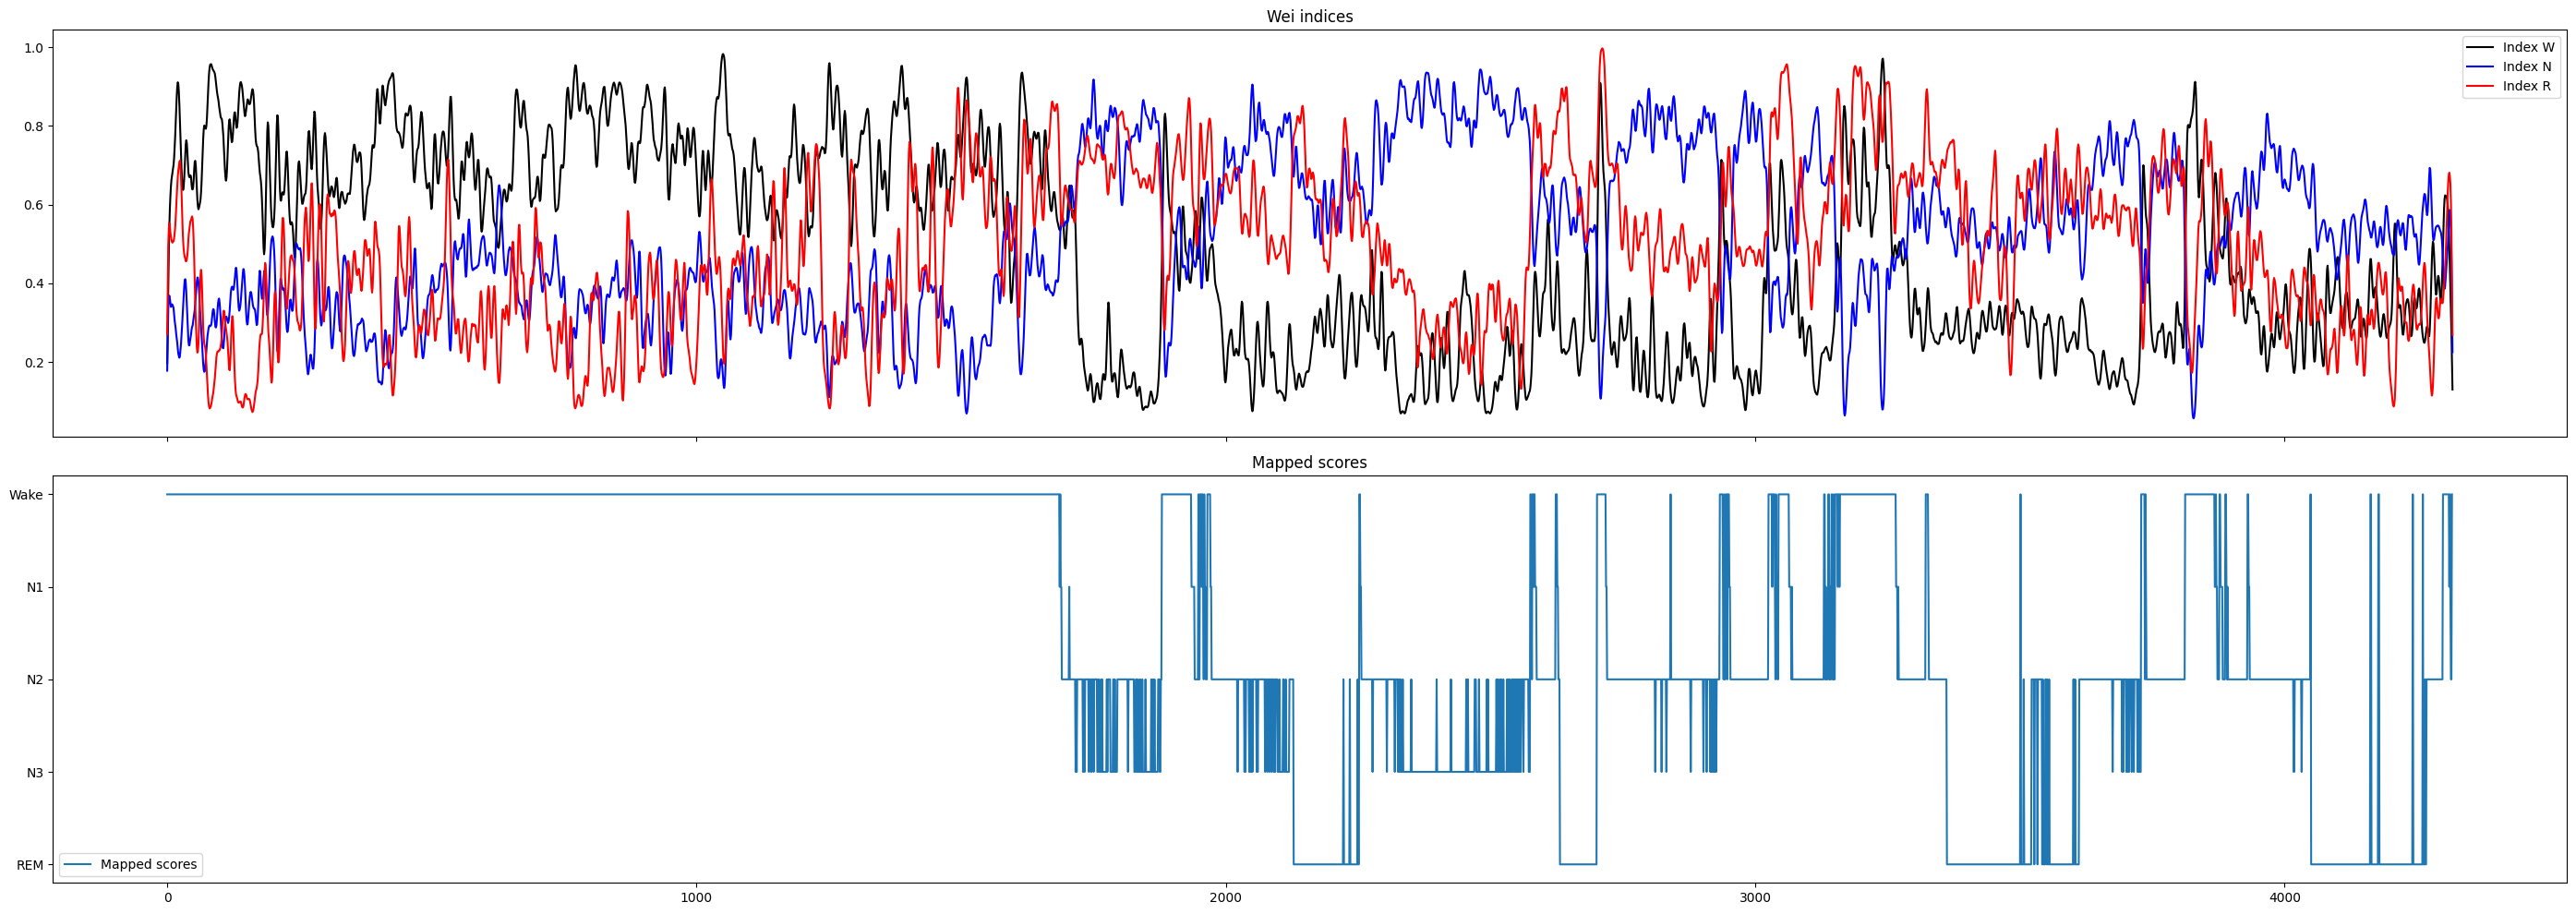

In [46]:
# All main indices

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize = (28, 10))
# Plot data on each subplot
ax1.plot(epochs, index_w_smoothed, label='Index W', color='black')
ax1.plot(epochs, index_n_smoothed, label='Index N', color='blue')
ax1.plot(epochs, index_r_smoothed, label='Index R', color='red')

ax2.plot(hypno_epochs, mapped_scores, label='Mapped scores')


# Add legends
ax1.legend()
ax2.legend()


# Add titles
ax1.set_title('Wei indices')
ax2.set_title('Mapped scores')
ax2.set_yticks([0, 1, 2, 3, 4])
ax2.set_yticklabels(state_labels)
ax2.invert_yaxis() 
# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig("Wei_indices_original.svg", format='svg')
# Show the plots
plt.show()

### New indexes

#### New WAKE (define and get index)

##### Compute new index + function

In [47]:
nindex_w = nindex_W(theta_norm, gamma_norm, EMG_norm)
nindex_w_log = np.log(nindex_w)
nindex_w_norm = wei_normalizing(nindex_w_log)
nindex_w_smoothed = np.convolve(np.convolve(np.convolve(nindex_w_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')

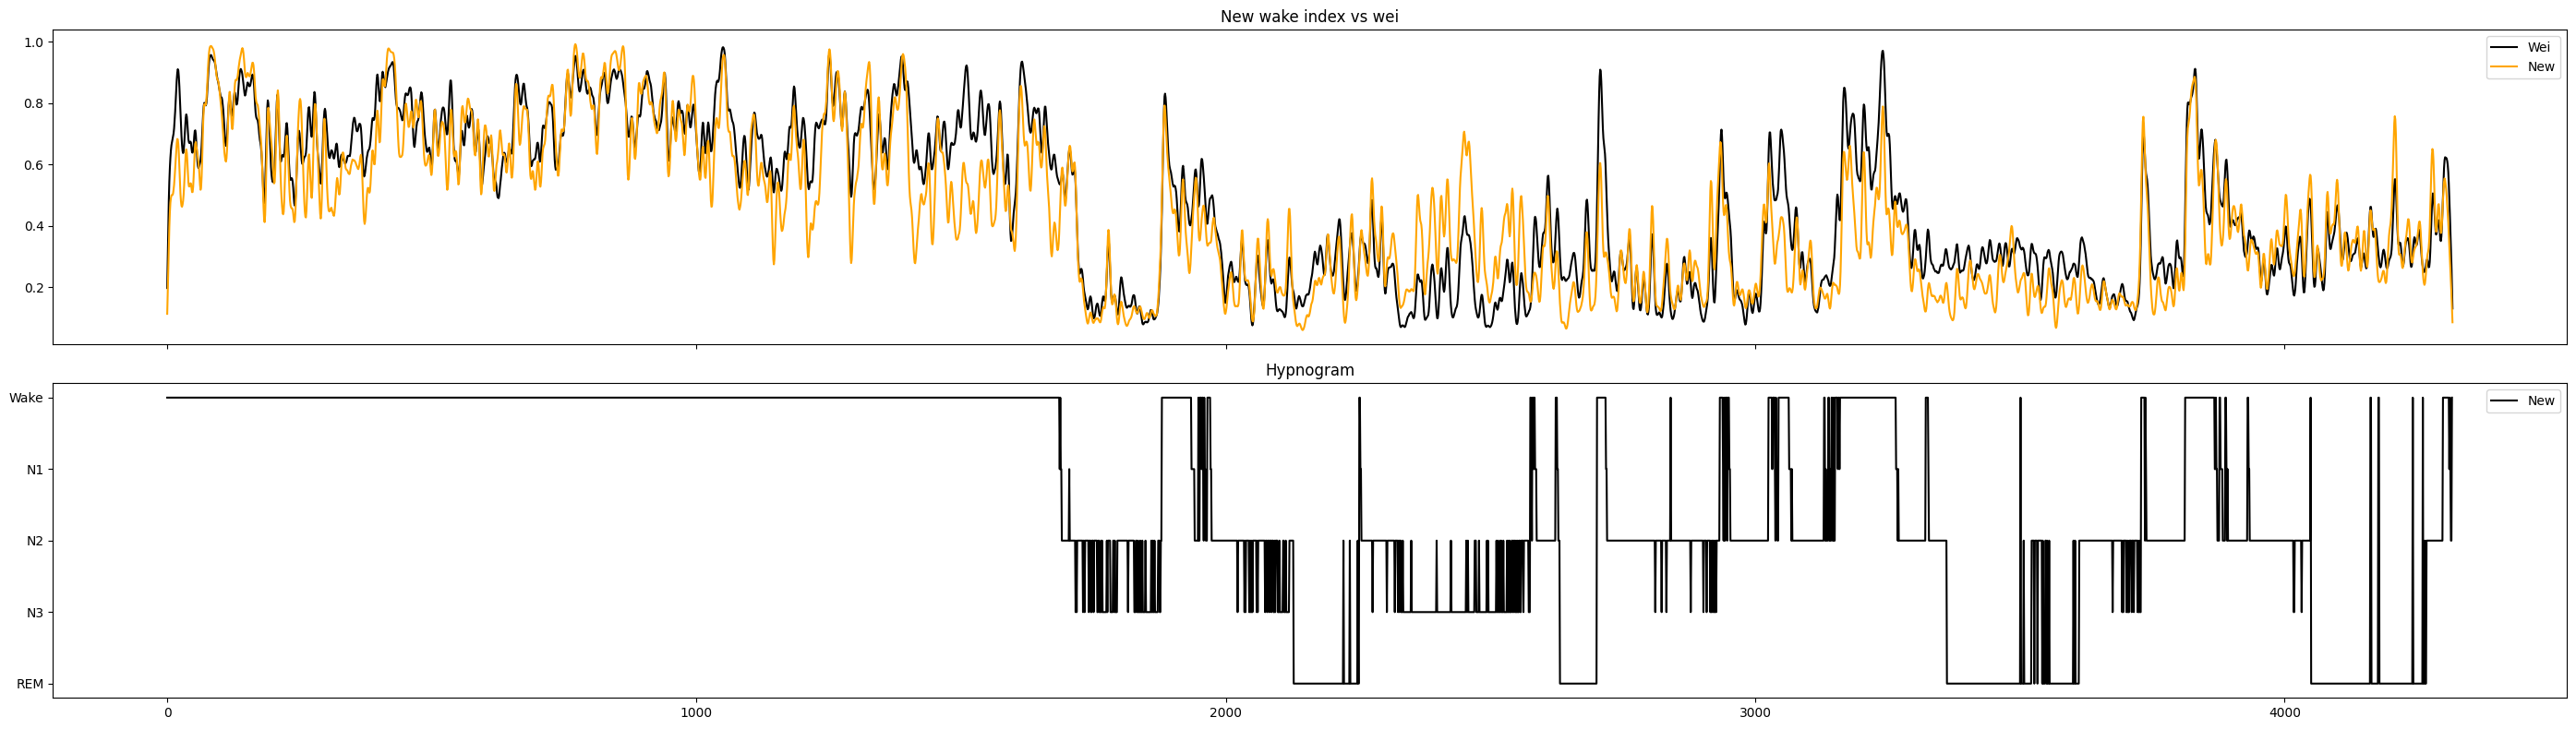

In [48]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize = (28, 8))

# Plot data on each subplot
ax1.plot(epochs, index_w_smoothed, label='Wei', color = 'black')
ax1.plot(epochs, nindex_w_smoothed, label='New', color = 'orange')
ax2.plot(hypno_epochs, mapped_scores, label='New', color = 'black')

ax1.set_title("New wake index vs wei")
ax2.set_title("Hypnogram")
# Add legends
ax1.legend()
ax2.legend()
ax2.set_yticks([0, 1, 2, 3, 4])
ax2.set_yticklabels(state_labels)
ax2.invert_yaxis() 
# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig("new_wake_index_vs_wei.svg", format='svg')
# Show the plots
plt.show()

##### All indices plot

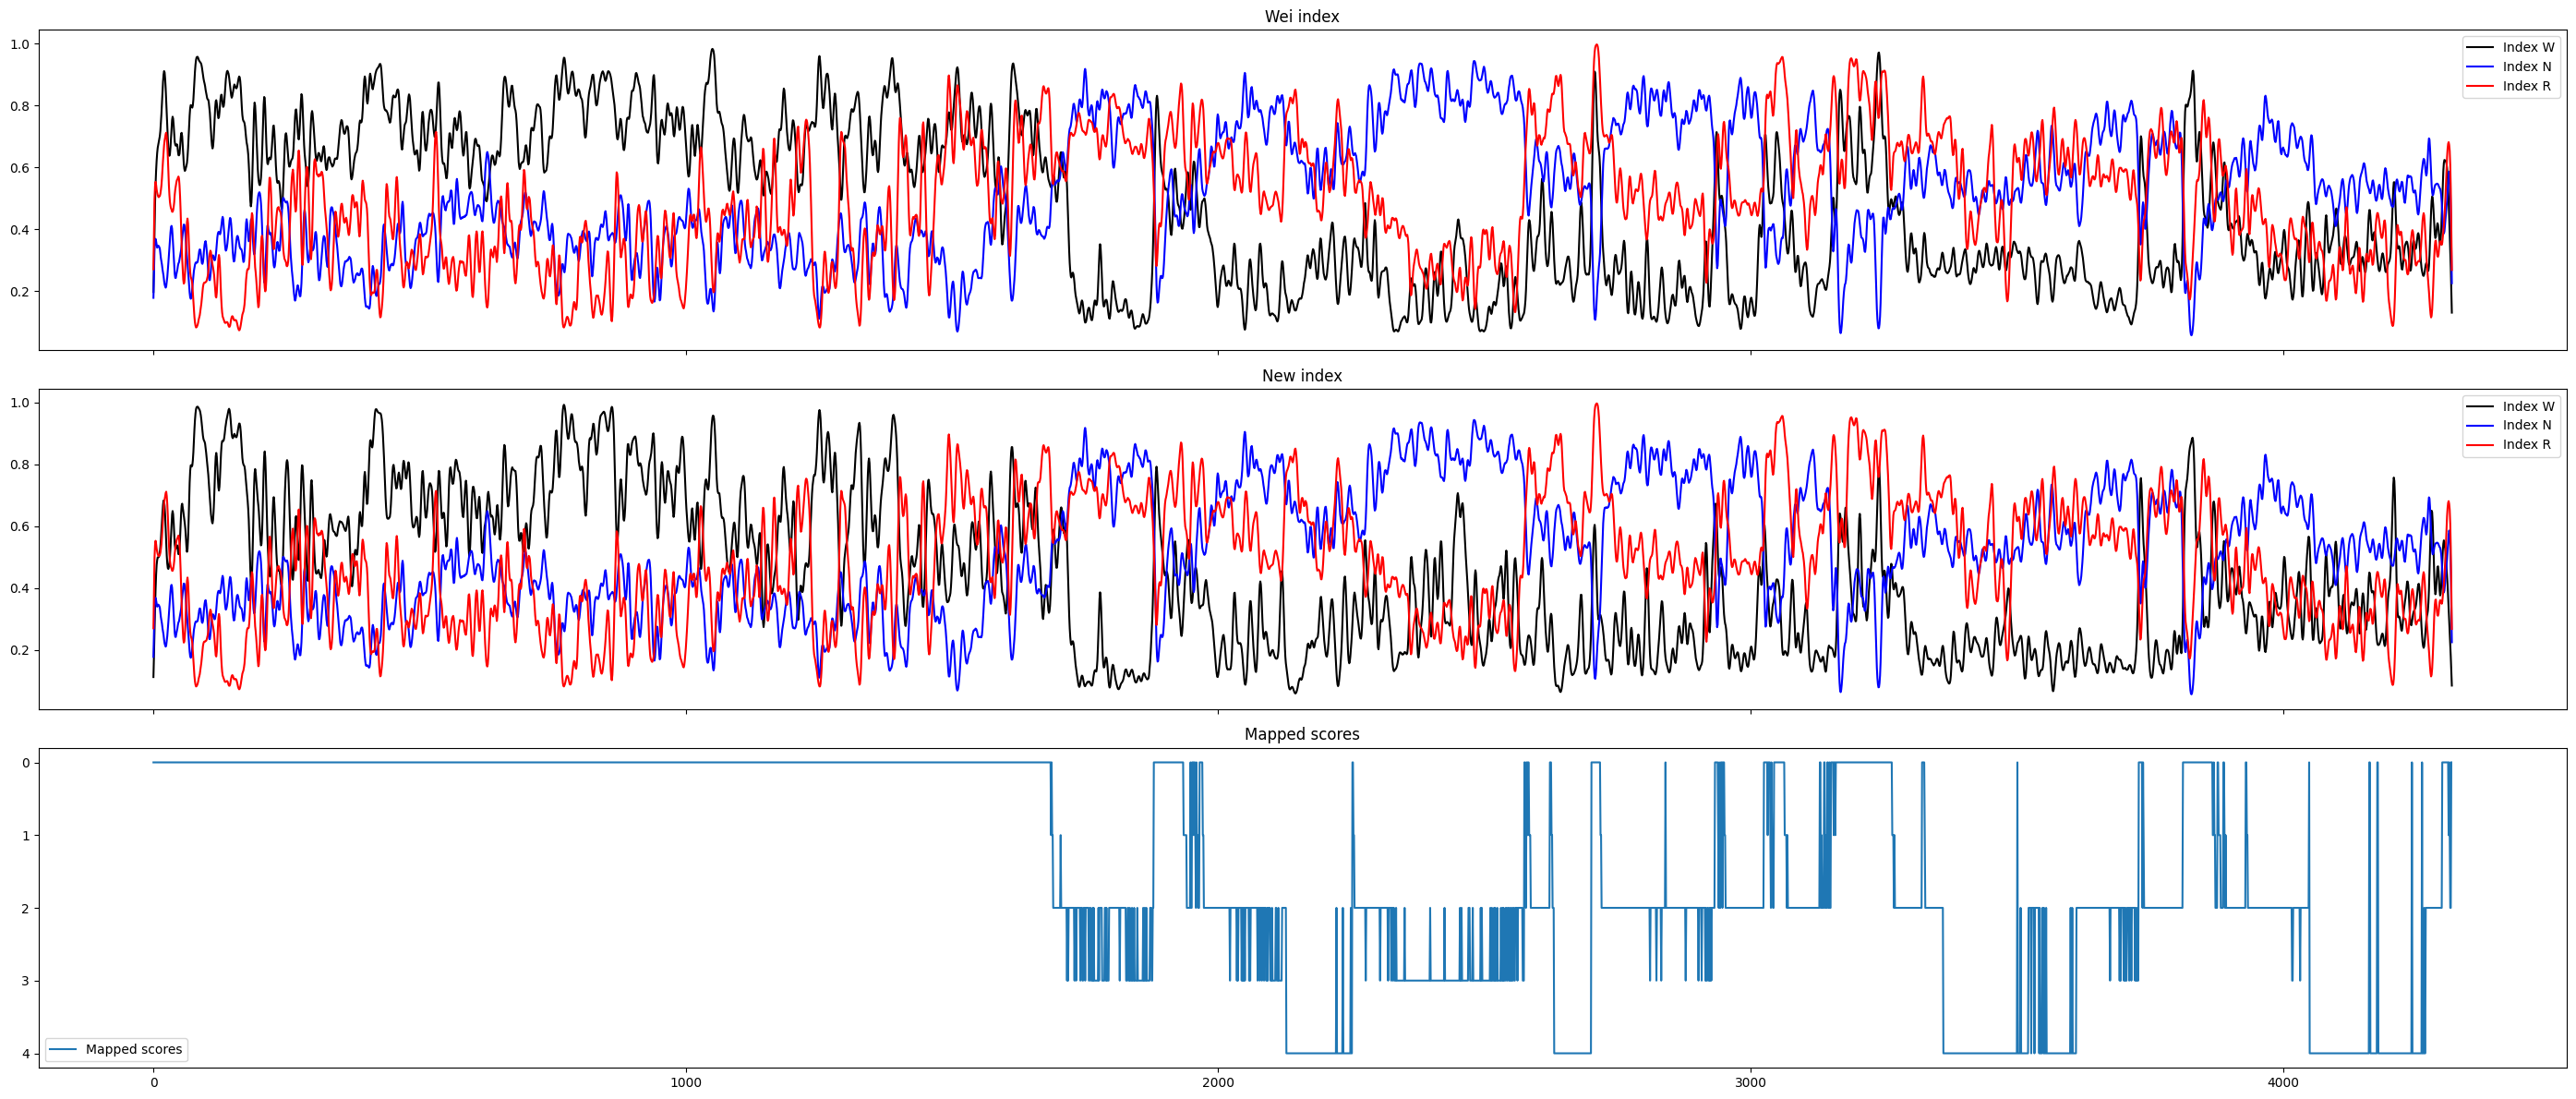

In [49]:
# All indices smoothed for better visualisation

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize = (28, 12))

# Plot data on each subplot
ax1.plot(epochs, index_w_smoothed, label='Index W', color ='black')
ax1.plot(epochs, index_n_smoothed, label='Index N', color ='blue')
ax1.plot(epochs, index_r_smoothed, label='Index R', color ='red')

ax2.plot(epochs, nindex_w_smoothed, label='Index W', color ='black')
ax2.plot(epochs, index_n_smoothed, label='Index N', color ='blue')
ax2.plot(epochs, index_r_smoothed, label='Index R', color ='red')


ax3.plot(hypno_epochs, mapped_scores, label='Mapped scores')

# Add legends
ax1.legend()
ax2.legend()
ax3.legend()

# Add titles
ax1.set_title('Wei index')
ax2.set_title('New index')
ax3.set_title('Mapped scores')

ax3.set_yticks([0, 1, 2, 3, 4])
# ax3.set_yticklabels(state_labels)
ax3.invert_yaxis() 

# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig("all_indices_new_wake_vs_wei.svg", format='svg')
# Show the plots
plt.show()

##### Barplots

###### Prerequisites

In [50]:
# Wei
index_Wake = [[],[],[]]
index_n1 = [[],[],[]]
index_n2 = [[],[],[]]
index_n3 = [[],[],[]]
index_REM = [[],[],[]]
score_labels = {0: 'Wake', 1: 'N1', 2: 'N2', 3: 'N3', 4: 'REM'}
mapped_scores_old = mapped_scores
mapped_scores = [score_labels[s] for s in mapped_scores]
for i, el in enumerate(mapped_scores):

  if el == 'Wake':
    index_Wake[0].append(index_w_smoothed[i])
    index_Wake[1].append(index_r_smoothed[i])
    index_Wake[2].append(index_n_smoothed[i])

  elif el == 'N1':
    index_n1[0].append(index_w_smoothed[i])
    index_n1[1].append(index_r_smoothed[i])
    index_n1[2].append(index_n_smoothed[i])
  elif el == 'N2':
    index_n2[0].append(index_w_smoothed[i])
    index_n2[1].append(index_r_smoothed[i])
    index_n2[2].append(index_n_smoothed[i])
  elif el == 'N3':
    index_n3[0].append(index_w_smoothed[i])
    index_n3[1].append(index_r_smoothed[i])
    index_n3[2].append(index_n_smoothed[i])
  elif el == 'REM':
    index_REM[0].append(index_w_smoothed[i])
    index_REM[1].append(index_r_smoothed[i])
    index_REM[2].append(index_n_smoothed[i])

# New
nindex_Wake = [[],[],[]]
nindex_n1 = [[],[],[]]
nindex_n2 = [[],[],[]]
nindex_n3 = [[],[],[]]
nindex_REM = [[],[],[]]
for i, el in enumerate(mapped_scores):
  if el == 'Wake':
    nindex_Wake[0].append(nindex_w_smoothed[i])
    nindex_Wake[1].append(index_r_smoothed[i])
    nindex_Wake[2].append(index_n_smoothed[i])

  elif el == 'N1':
    nindex_n1[0].append(nindex_w_smoothed[i])
    nindex_n1[1].append(index_r_smoothed[i])
    nindex_n1[2].append(index_n_smoothed[i])
  elif el == 'N2':
    nindex_n2[0].append(nindex_w_smoothed[i])
    nindex_n2[1].append(index_r_smoothed[i])
    nindex_n2[2].append(index_n_smoothed[i])
  elif el == 'N3':
    nindex_n3[0].append(nindex_w_smoothed[i])
    nindex_n3[1].append(index_r_smoothed[i])
    nindex_n3[2].append(index_n_smoothed[i])
  elif el == 'REM':
    nindex_REM[0].append(nindex_w_smoothed[i])
    nindex_REM[1].append(index_r_smoothed[i])
    nindex_REM[2].append(index_n_smoothed[i])

In [51]:
# Wei
wake_w = np.average(index_Wake[0])
wake_r = np.average(index_Wake[1])
wake_n = np.average(index_Wake[2])
n1_w = np.average(index_n1[0])
n1_r = np.average(index_n1[1])
n1_n = np.average(index_n1[2])
n2_w = np.average(index_n2[0])
n2_r = np.average(index_n2[1])
n2_n = np.average(index_n2[2])
n3_w = np.average(index_n3[0])
n3_r = np.average(index_n3[1])
n3_n = np.average(index_n3[2])
REM_w = np.average(index_REM[0])
REM_r = np.average(index_REM[1])
REM_n = np.average(index_REM[2])

# New
nwake_w = np.average(nindex_Wake[0])
nwake_r = np.average(nindex_Wake[1])
nwake_n = np.average(nindex_Wake[2])
nn1_w = np.average(nindex_n1[0])
nn1_r = np.average(nindex_n1[1])
nn1_n = np.average(nindex_n1[2])
nn2_w = np.average(nindex_n2[0])
nn2_r = np.average(nindex_n2[1])
nn2_n = np.average(nindex_n2[2])
nn3_w = np.average(nindex_n3[0])
nn3_r = np.average(nindex_n3[1])
nn3_n = np.average(nindex_n3[2])
nREM_w = np.average(nindex_REM[0])
nREM_r = np.average(nindex_REM[1])
nREM_n = np.average(nindex_REM[2])

###### Barplots

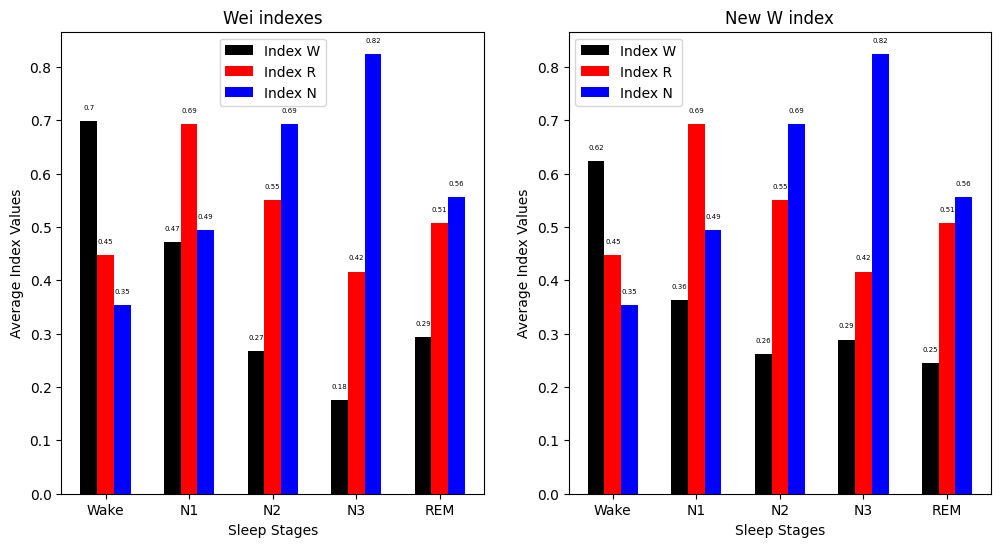

In [52]:
plt.figure(figsize=(12, 6))

# Wei indexes
plt.subplot(1, 2, 1)
categories = ['Wake', 'N1', 'N2','N3', 'REM']
index_types = ['Index_w', 'Index_r', 'Index_n']
values_wake = [wake_w, n1_w, n2_w, n3_w, REM_w]
values_REM = [wake_r, n1_r, n2_r, n3_r, REM_r]
values_NREM = [wake_n, n1_n, n2_n, n3_n, REM_n]
x = np.arange(len(categories))
bar_width = 0.2
# Create bar plots
plt.bar(x - bar_width, values_wake, width=bar_width, label='Index W', color = 'black')
plt.bar(x, values_REM, width=bar_width, label='Index R', color = 'red',)
plt.bar(x + bar_width, values_NREM, width=bar_width, label='Index N', color = 'blue')
# Add labels and title
plt.xlabel('Sleep Stages')
plt.ylabel('Average Index Values')
plt.title('Wei indexes')
plt.xticks(x, categories)
plt.legend()

fontsize = 5

for i in range(len(categories)):
    plt.text(x[i] - bar_width, values_wake[i] + 0.02, str(round(values_wake[i], 2)), ha='center', va='bottom', fontsize=fontsize)
    plt.text(x[i], values_REM[i] + 0.02, str(round(values_REM[i], 2)), ha='center', va='bottom', fontsize=fontsize)
    plt.text(x[i] + bar_width, values_NREM[i] + 0.02, str(round(values_NREM[i], 2)), ha='center', va='bottom', fontsize=fontsize)

# New W index
plt.subplot(1, 2, 2)
categories = ['Wake', 'N1', 'N2','N3', 'REM']
index_types = ['Index_w', 'Index_r', 'Index_n']
values_wake = [nwake_w, nn1_w, nn2_w, nn3_w, nREM_w]
values_REM = [nwake_r, nn1_r, nn2_r, nn3_r, nREM_r]
values_NREM = [nwake_n, nn1_n, nn2_n, nn3_n, nREM_n]
x = np.arange(len(categories))
bar_width = 0.2
# Create bar plots
plt.bar(x - bar_width, values_wake, width=bar_width, label='Index W', color = 'black')
plt.bar(x, values_REM, width=bar_width, label='Index R', color = 'red',)
plt.bar(x + bar_width, values_NREM, width=bar_width, label='Index N', color = 'blue')
# Add labels and title
plt.xlabel('Sleep Stages')
plt.ylabel('Average Index Values')
plt.title('New W index')
plt.xticks(x, categories)
plt.legend()

for i in range(len(categories)):
    plt.text(x[i] - bar_width, values_wake[i] + 0.02, str(round(values_wake[i], 2)), ha='center', va='bottom', fontsize=fontsize)
    plt.text(x[i], values_REM[i] + 0.02, str(round(values_REM[i], 2)), ha='center', va='bottom', fontsize=fontsize)
    plt.text(x[i] + bar_width, values_NREM[i] + 0.02, str(round(values_NREM[i], 2)), ha='center', va='bottom', fontsize=fontsize)
plt.savefig("wei_new_wake_barplot.svg", format='svg')

#### New REM (define and get index)

##### Compute new index + function

In [53]:
nindex_r = nindex_R(delta_norm, theta_norm, sigma_norm, EMG_norm, gamma_norm)
nindex_r_log = np.log(nindex_r)
nindex_r_norm = wei_normalizing(nindex_r_log)
nindex_r_smoothed = np.convolve(np.convolve(np.convolve(nindex_r_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
# nindex_r_smoothed_n = np.mean(np.stack([nindex_r_smoothed, rem_features]), axis=0)
# nindex_r_smoothed_n = spike_conflict_avg(nindex_r_smoothed, rem_features)

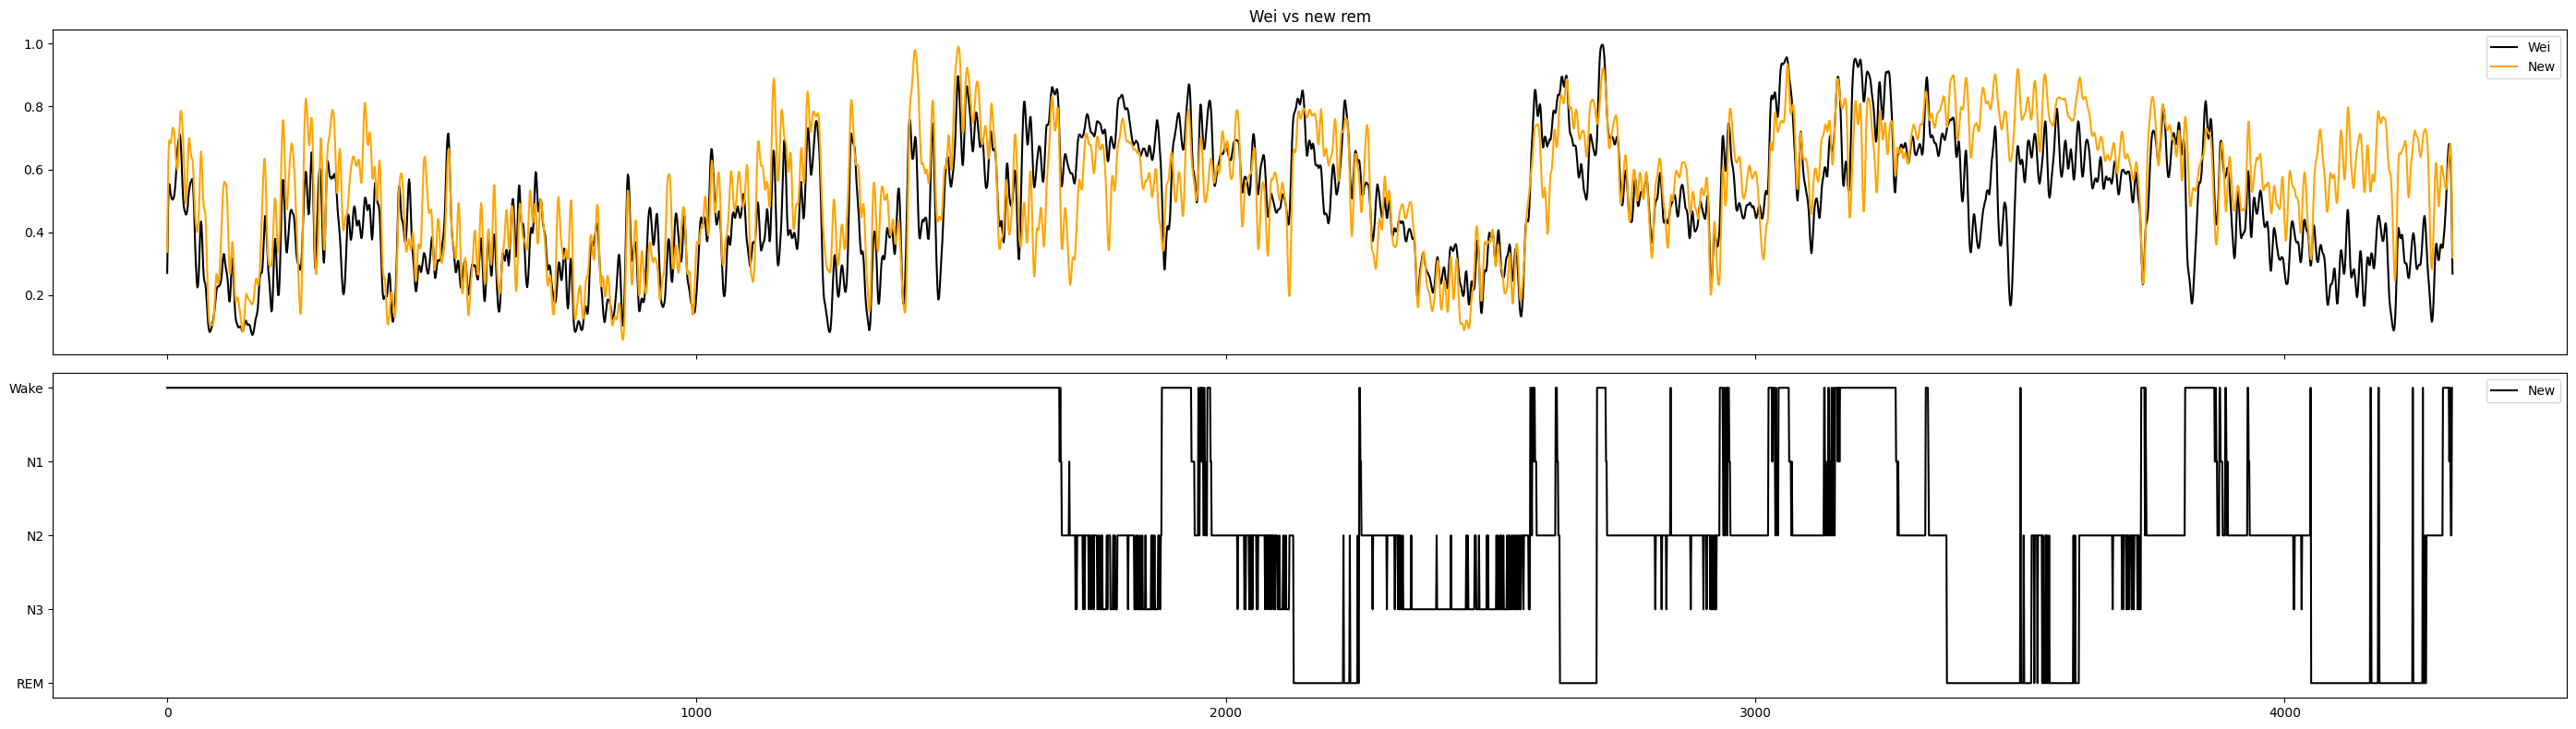

In [54]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize = (28, 8))

# Plot data on each subplot
ax1.plot(epochs, index_r_smoothed, label='Wei', color = 'black')
ax1.plot(epochs, nindex_r_smoothed, label='New', color = 'orange')
ax2.plot(hypno_epochs, mapped_scores, label='New', color = 'black')
ax1.set_title("Wei vs new rem")
# Add legends
ax1.legend()
ax2.legend()
ax2.set_yticks([0, 1, 2, 3, 4])
ax2.set_yticklabels(state_labels)
ax2.invert_yaxis() 
# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig("new_rem_vs_wei.svg", format='svg')
# Show the plots
plt.show()

##### All indices plot

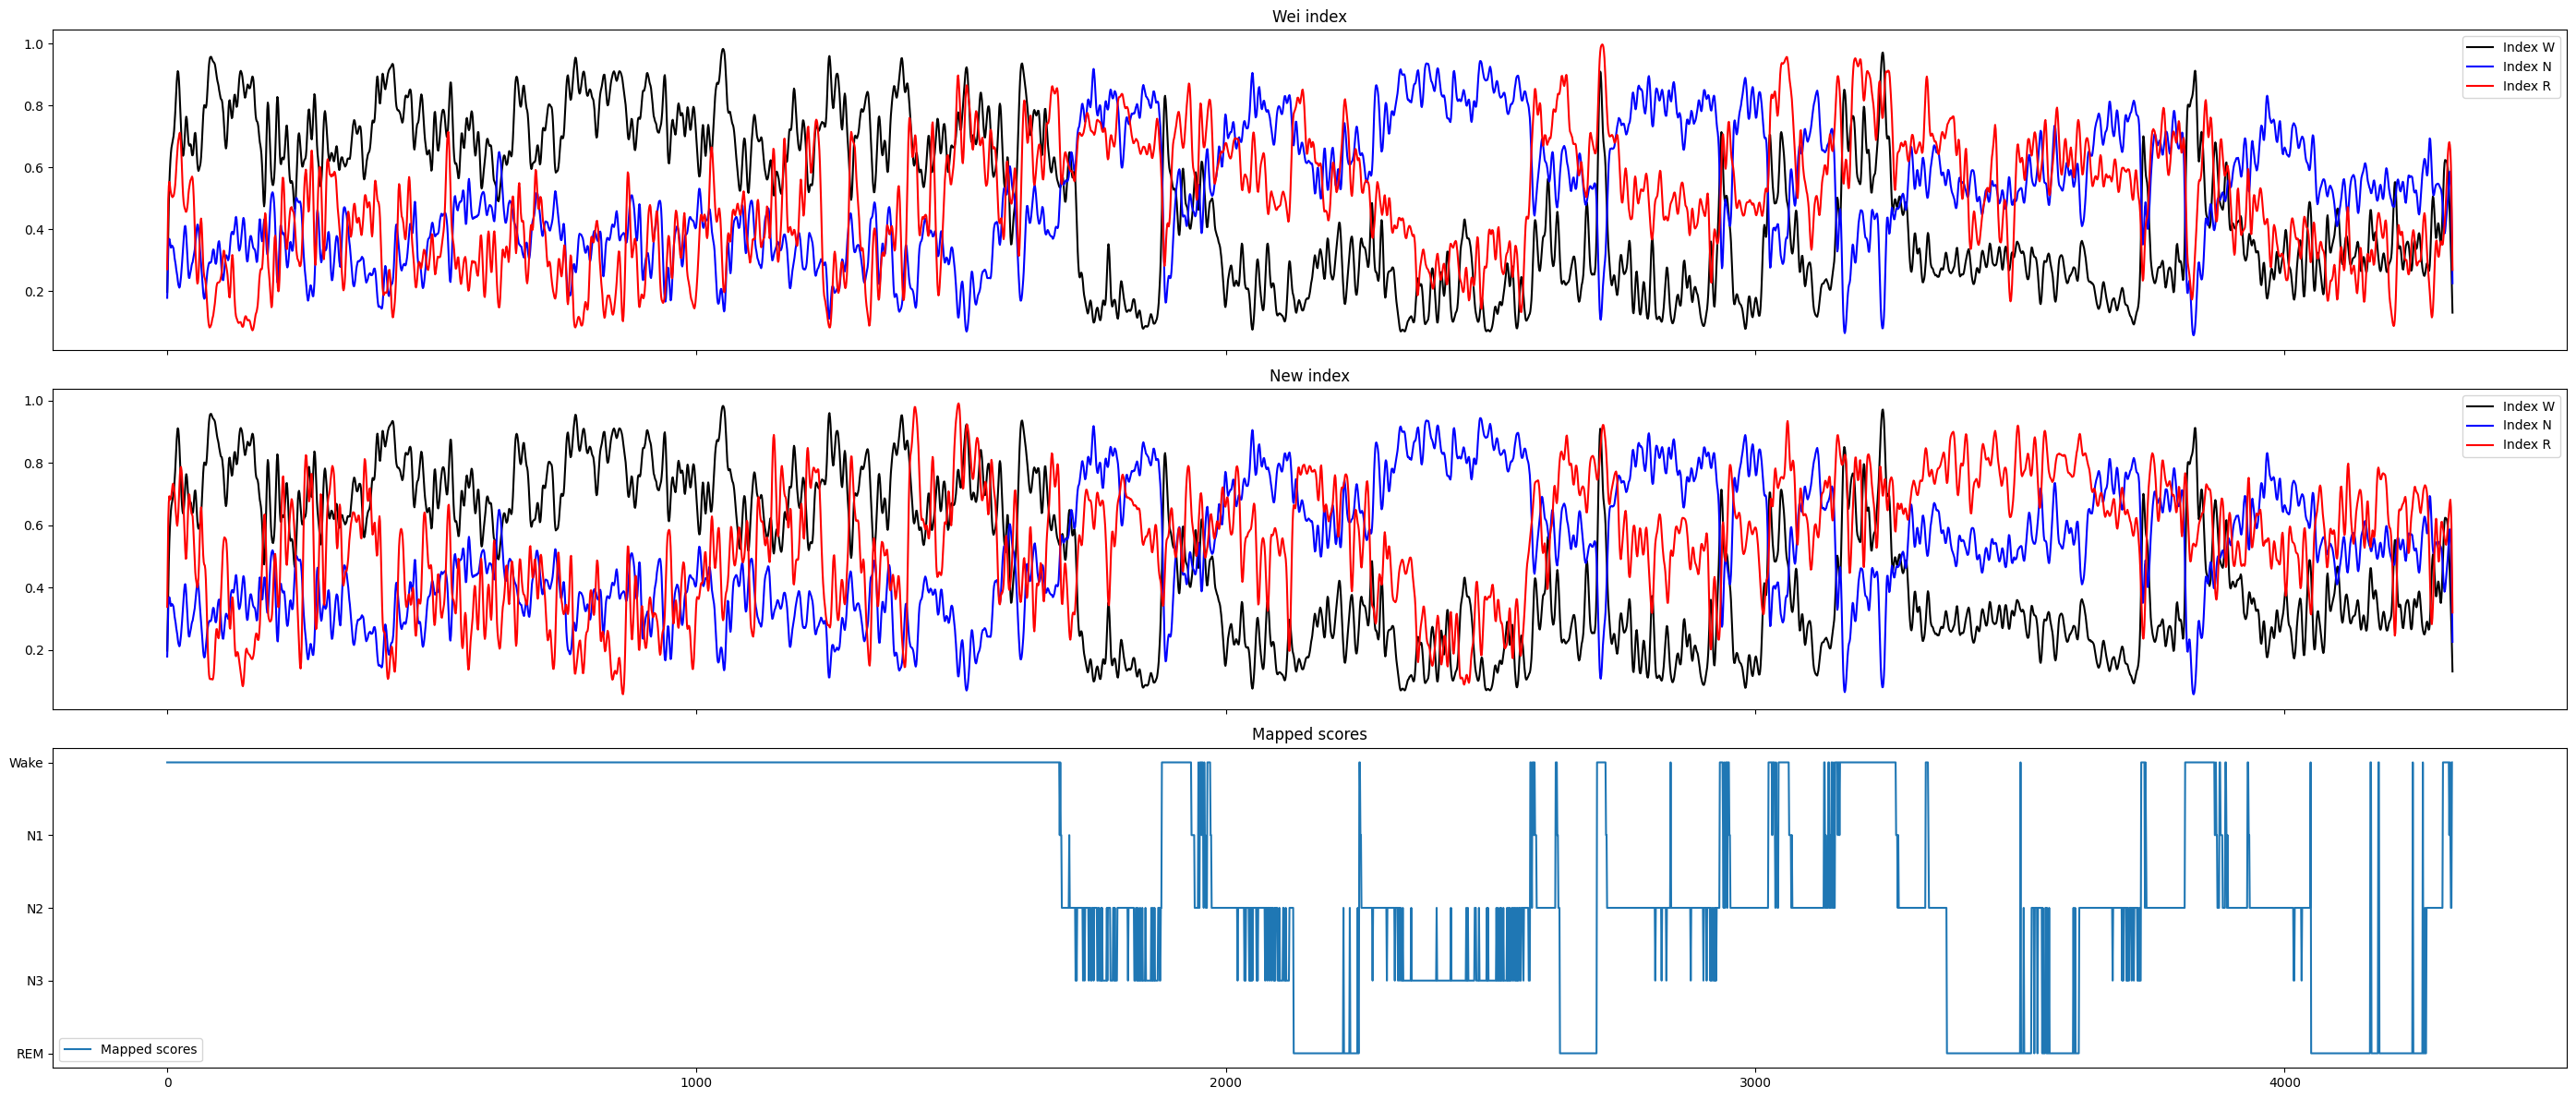

In [55]:
# All indices smoothed for better visualisation

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize = (28, 12))

# Plot data on each subplot
ax1.plot(epochs, index_w_smoothed, label='Index W', color ='black')
ax1.plot(epochs, index_n_smoothed, label='Index N', color ='blue')
ax1.plot(epochs, index_r_smoothed, label='Index R', color ='red')

ax2.plot(epochs, index_w_smoothed, label='Index W', color ='black')
ax2.plot(epochs, index_n_smoothed, label='Index N', color ='blue')
ax2.plot(epochs, nindex_r_smoothed, label='Index R', color ='red')


ax3.plot(hypno_epochs, mapped_scores, label='Mapped scores')

# Add legends
ax1.legend()
ax2.legend()
ax3.legend()

# Add titles
ax1.set_title('Wei index')
ax2.set_title('New index')
ax3.set_title('Mapped scores')
ax3.set_yticks([0, 1, 2, 3, 4])
ax3.set_yticklabels(state_labels)
ax3.invert_yaxis() 
# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig("wei_vs_new_rem_all_indices.svg", format='svg')
# Show the plots
plt.show()

##### Barplots

###### Prerequisites

In [56]:
# Wei
index_Wake = [[],[],[]]
index_n1 = [[],[],[]]
index_n2 = [[],[],[]]
index_n3 = [[],[],[]]
index_REM = [[],[],[]]
for i, el in enumerate(mapped_scores):

  if el == 'Wake':
    index_Wake[0].append(index_w_smoothed[i])
    index_Wake[1].append(index_r_smoothed[i])
    index_Wake[2].append(index_n_smoothed[i])

  elif el == 'N1':
    index_n1[0].append(index_w_smoothed[i])
    index_n1[1].append(index_r_smoothed[i])
    index_n1[2].append(index_n_smoothed[i])
  elif el == 'N2':
    index_n2[0].append(index_w_smoothed[i])
    index_n2[1].append(index_r_smoothed[i])
    index_n2[2].append(index_n_smoothed[i])
  elif el == 'N3':
    index_n3[0].append(index_w_smoothed[i])
    index_n3[1].append(index_r_smoothed[i])
    index_n3[2].append(index_n_smoothed[i])
  elif el == 'REM':
    index_REM[0].append(index_w_smoothed[i])
    index_REM[1].append(index_r_smoothed[i])
    index_REM[2].append(index_n_smoothed[i])
# New
nindex_Wake = [[],[],[]]
nindex_NREM = [[],[],[]]
nindex_REM = [[],[],[]]
for i, el in enumerate(mapped_scores):

  if el == 'Wake':
    nindex_Wake[0].append(index_w_smoothed[i])
    nindex_Wake[1].append(nindex_r_smoothed[i])
    nindex_Wake[2].append(index_n_smoothed[i])
  elif el == 'N1':
    nindex_n1[0].append(index_w_smoothed[i])
    nindex_n1[1].append(nindex_r_smoothed[i])
    nindex_n1[2].append(index_n_smoothed[i])
  elif el == 'N2':
    nindex_n2[0].append(index_w_smoothed[i])
    nindex_n2[1].append(nindex_r_smoothed[i])
    nindex_n2[2].append(index_n_smoothed[i])
  elif el == 'N3':
    nindex_n3[0].append(index_w_smoothed[i])
    nindex_n3[1].append(nindex_r_smoothed[i])
    nindex_n3[2].append(index_n_smoothed[i])
  elif el == 'REM':
    nindex_REM[0].append(index_w_smoothed[i])
    nindex_REM[1].append(nindex_r_smoothed[i])
    nindex_REM[2].append(index_n_smoothed[i])

In [57]:
# Wei
wake_w = np.average(index_Wake[0])
wake_r = np.average(index_Wake[1])
wake_n = np.average(index_Wake[2])
n1_w = np.average(index_n1[0])
n1_r = np.average(index_n1[1])
n1_n = np.average(index_n1[2])
n2_w = np.average(index_n2[0])
n2_r = np.average(index_n2[1])
n2_n = np.average(index_n2[2])
n3_w = np.average(index_n3[0])
n3_r = np.average(index_n3[1])
n3_n = np.average(index_n3[2])
REM_w = np.average(index_REM[0])
REM_r = np.average(index_REM[1])
REM_n = np.average(index_REM[2])

# New
nwake_w = np.average(nindex_Wake[0])
nwake_r = np.average(nindex_Wake[1])
nwake_n = np.average(nindex_Wake[2])
nn1_w = np.average(nindex_n1[0])
nn1_r = np.average(nindex_n1[1])
nn1_n = np.average(nindex_n1[2])
nn2_w = np.average(nindex_n2[0])
nn2_r = np.average(nindex_n2[1])
nn2_n = np.average(nindex_n2[2])
nn3_w = np.average(nindex_n3[0])
nn3_r = np.average(nindex_n3[1])
nn3_n = np.average(nindex_n3[2])
nREM_w = np.average(nindex_REM[0])
nREM_r = np.average(nindex_REM[1])
nREM_n = np.average(nindex_REM[2])

###### Barplots

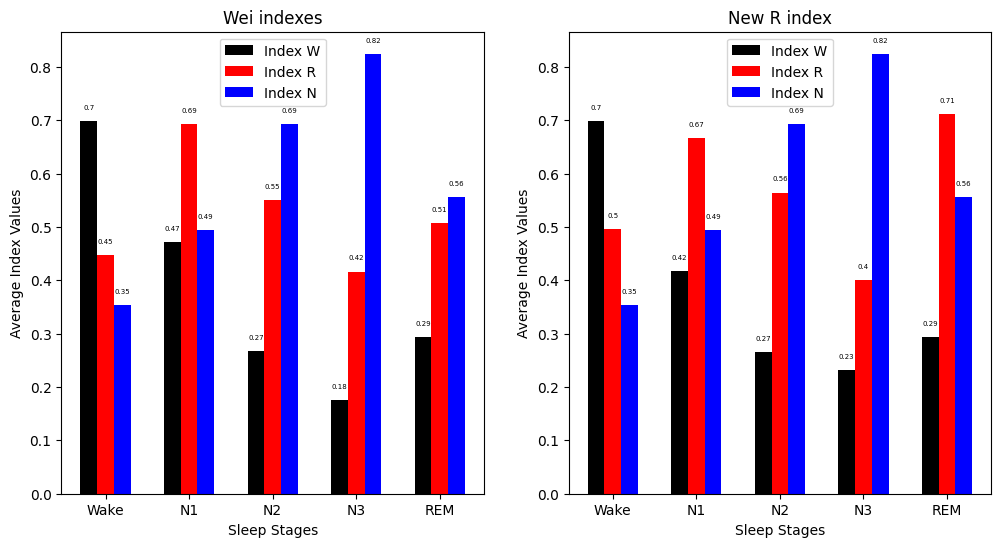

In [58]:
plt.figure(figsize=(12, 6))

# Wei indexes
plt.subplot(1, 2, 1)
categories = ['Wake', 'N1', 'N2','N3', 'REM']
index_types = ['Index_w', 'Index_r', 'Index_n']
values_wake = [wake_w, n1_w, n2_w, n3_w, REM_w]
values_REM = [wake_r, n1_r, n2_r, n3_r, REM_r]
values_NREM = [wake_n, n1_n, n2_n, n3_n, REM_n]

x = np.arange(len(categories))
bar_width = 0.2
fontsize = 5
# Create bar plots
plt.bar(x - bar_width, values_wake, width=bar_width, label='Index W', color = 'black')
plt.bar(x, values_REM, width=bar_width, label='Index R', color = 'red',)
plt.bar(x + bar_width, values_NREM, width=bar_width, label='Index N', color = 'blue')
# Add labels and title
plt.xlabel('Sleep Stages')
plt.ylabel('Average Index Values')
plt.title('Wei indexes')
plt.xticks(x, categories)
plt.legend()

for i in range(len(categories)):
    plt.text(x[i] - bar_width, values_wake[i] + 0.02, str(round(values_wake[i], 2)), ha='center', va='bottom', fontsize=fontsize)
    plt.text(x[i], values_REM[i] + 0.02, str(round(values_REM[i], 2)), ha='center', va='bottom', fontsize=fontsize)
    plt.text(x[i] + bar_width, values_NREM[i] + 0.02, str(round(values_NREM[i], 2)), ha='center', va='bottom', fontsize=fontsize)

# New W index
plt.subplot(1, 2, 2)
categories = ['Wake', 'N1', 'N2','N3', 'REM']
index_types = ['Index_w', 'Index_r', 'Index_n']
values_wake = [nwake_w, nn1_w, nn2_w, nn3_w, nREM_w]
values_REM = [nwake_r, nn1_r, nn2_r, nn3_r, nREM_r]
values_NREM = [nwake_n, nn1_n, nn2_n, nn3_n, nREM_n]
x = np.arange(len(categories))
bar_width = 0.2
# Create bar plots
plt.bar(x - bar_width, values_wake, width=bar_width, label='Index W', color = 'black')
plt.bar(x, values_REM, width=bar_width, label='Index R', color = 'red',)
plt.bar(x + bar_width, values_NREM, width=bar_width, label='Index N', color = 'blue')
# Add labels and title
plt.xlabel('Sleep Stages')
plt.ylabel('Average Index Values')
plt.title('New R index')
plt.xticks(x, categories)
plt.legend()

for i in range(len(categories)):
    plt.text(x[i] - bar_width, values_wake[i] + 0.02, str(round(values_wake[i], 2)), ha='center', va='bottom', fontsize=fontsize)
    plt.text(x[i], values_REM[i] + 0.02, str(round(values_REM[i], 2)), ha='center', va='bottom', fontsize=fontsize)
    plt.text(x[i] + bar_width, values_NREM[i] + 0.02, str(round(values_NREM[i], 2)), ha='center', va='bottom', fontsize=fontsize)
    
plt.savefig("new_rem_vs_wei_bar.svg", format='svg', dpi=300)

#### New NREM (define and get index)

##### Compute new index + function

In [59]:
nindex_n = nindex_N(delta_norm, sigma_norm, gamma_norm)
nindex_n_log = np.log(nindex_n)
nindex_n_norm = wei_normalizing(nindex_n_log)
nindex_n_smoothed = np.convolve(np.convolve(np.convolve(nindex_n_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')

In [60]:
nindex_n2 = nindex_N2(delta_norm, theta_norm, sigma_norm, EMG_norm, gamma_norm)
nindex_n2_log = np.log(nindex_n2)
nindex_n2_norm = wei_normalizing(nindex_n2_log)
nindex_n2_smoothed = np.convolve(np.convolve(np.convolve(nindex_n2_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')

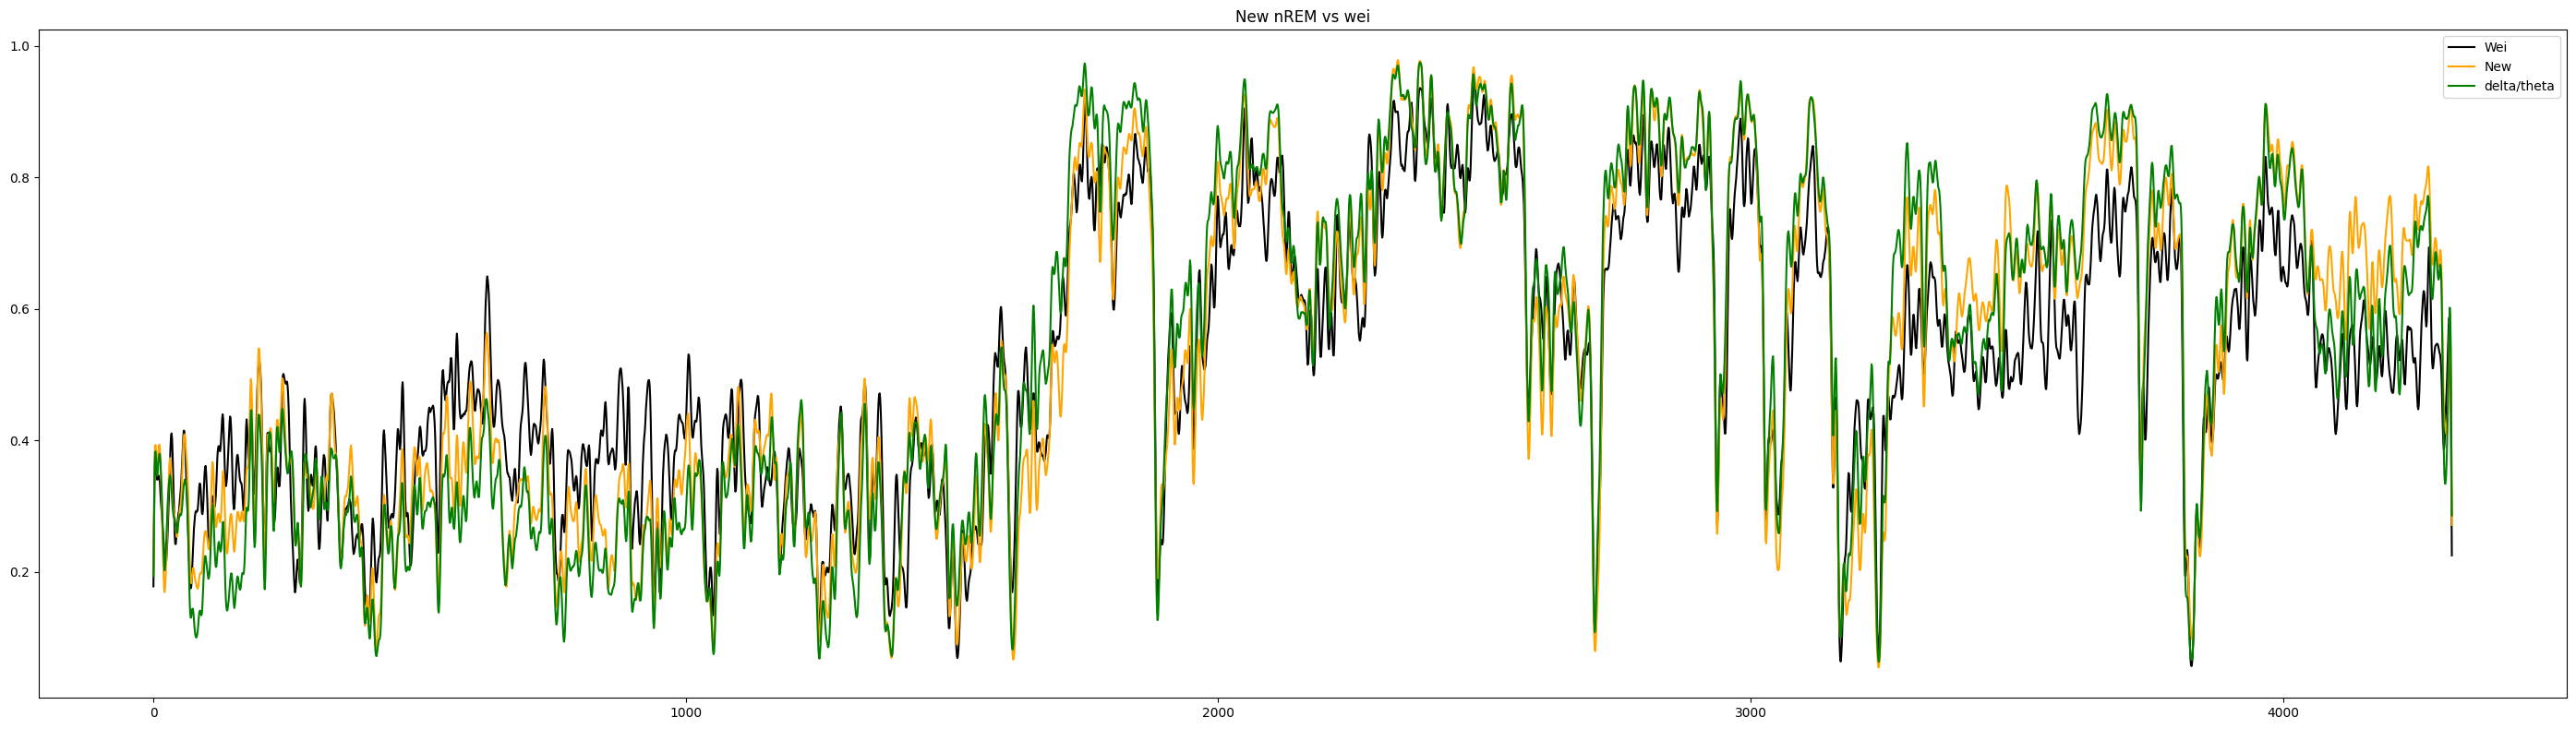

In [61]:
fig, (ax1) = plt.subplots(1, 1, sharex=True, figsize = (28, 8))

# Plot data on each subplot
ax1.plot(epochs, index_n_smoothed, label='Wei', color = 'black')
ax1.plot(epochs, nindex_n_smoothed, label='New', color = 'orange')
ax1.plot(epochs, nindex_n2_smoothed, label='delta/theta', color = 'green')
ax1.set_title("New nREM vs wei")
# Add legendsg
ax1.legend()

# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig("new_index_n_vs_wei.svg", format='svg', dpi=300)
# Show the plots
plt.show()

##### All indices plot

Amount of indices: 4318


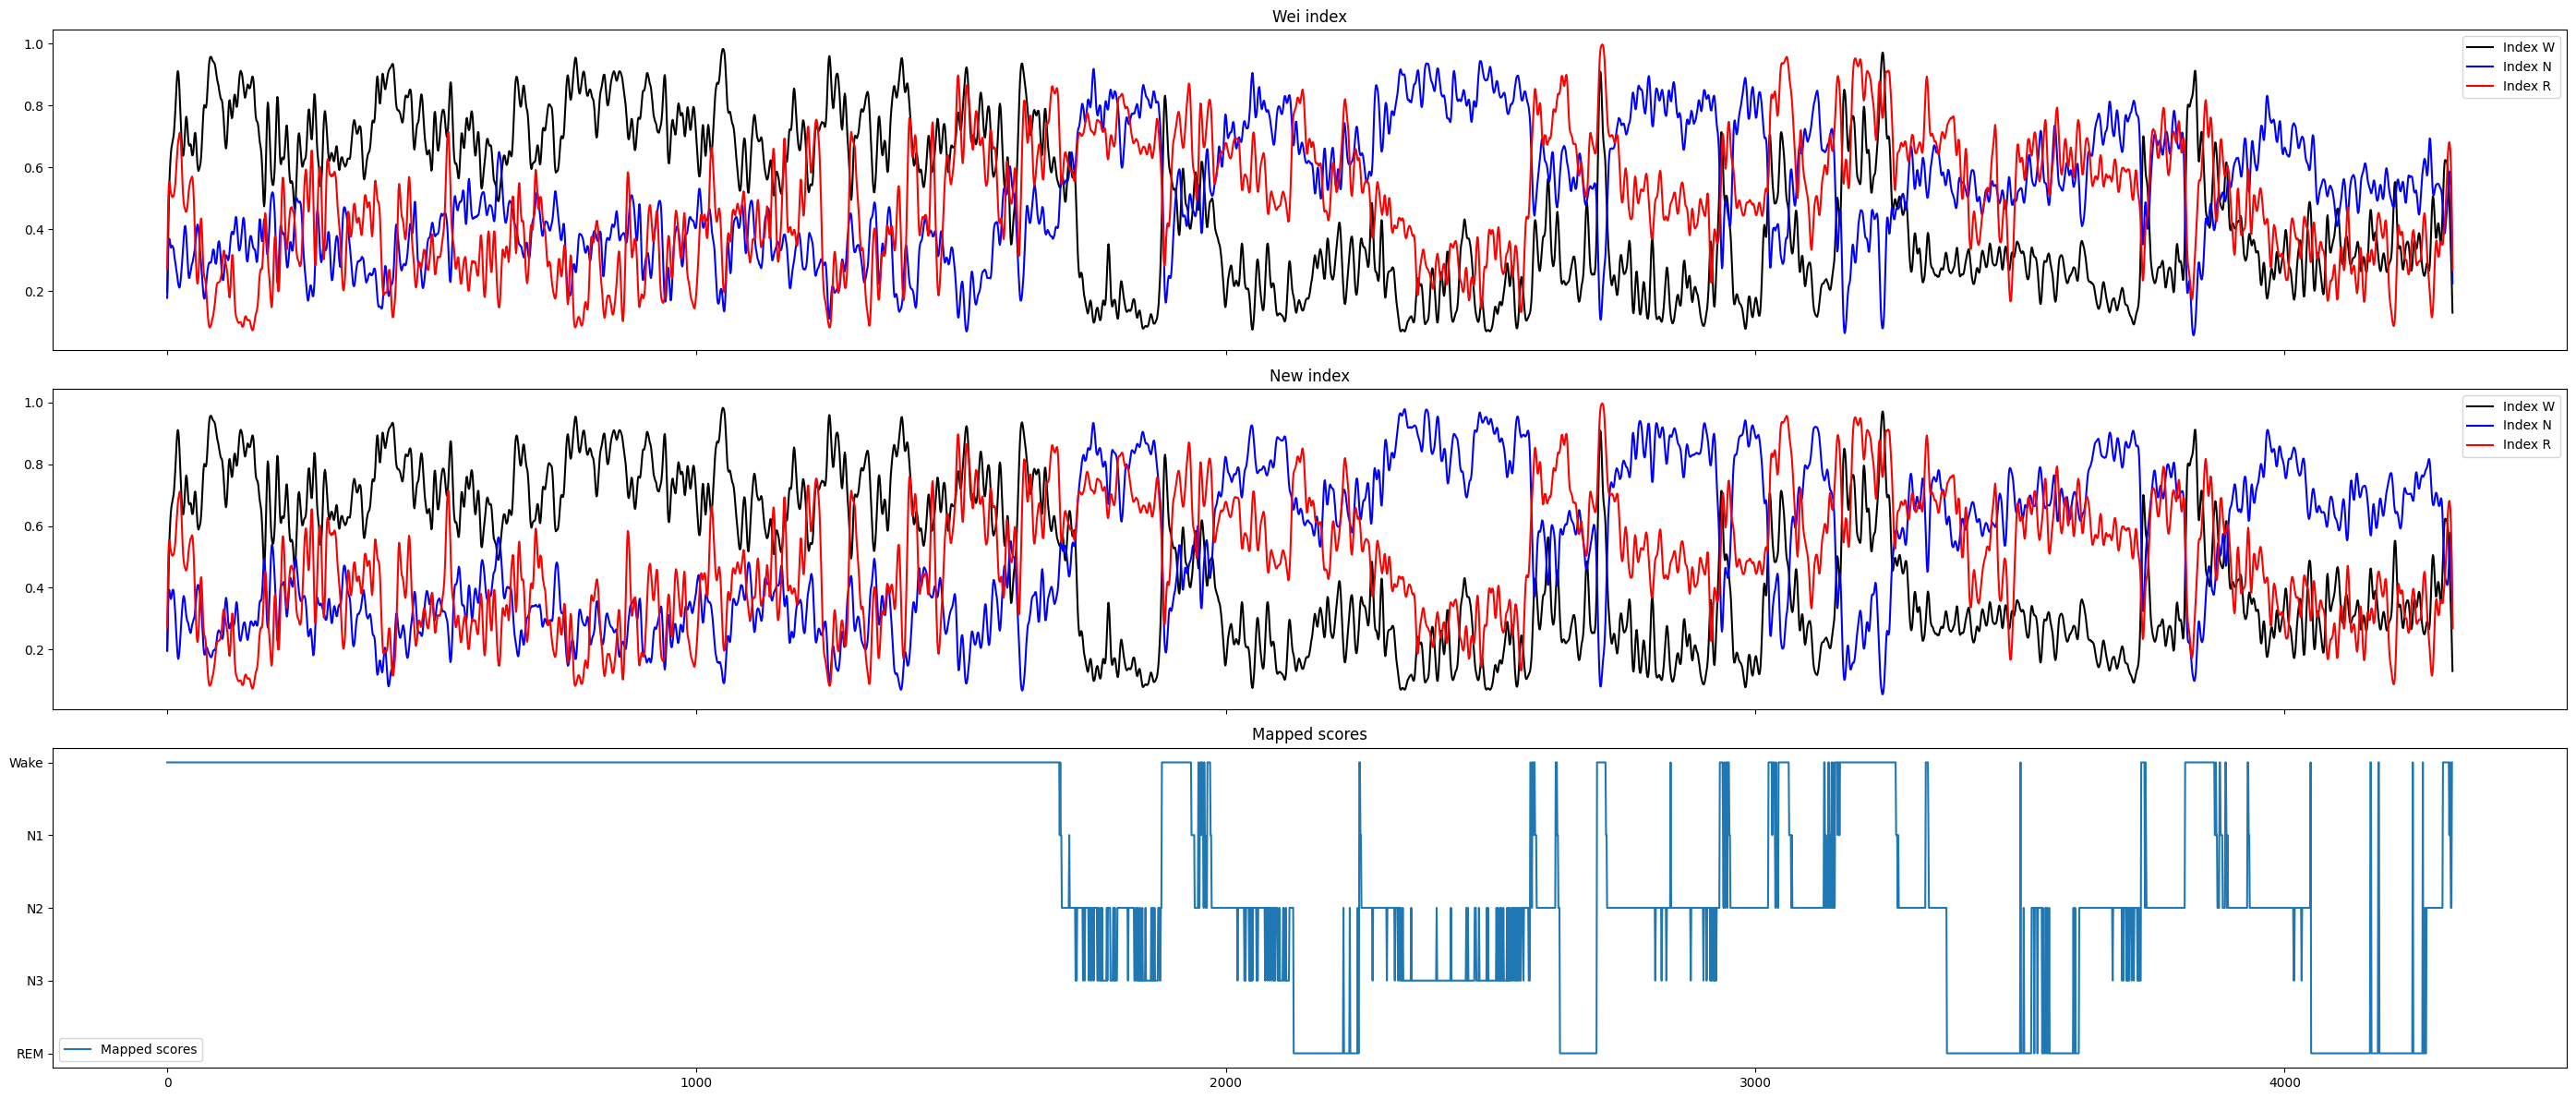

In [62]:
# All indices smoothed for better visualisation

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize = (28, 12))

# Plot data on each subplot
ax1.plot(epochs, index_w_smoothed, label='Index W', color ='black')
ax1.plot(epochs, index_n_smoothed, label='Index N', color ='blue')
ax1.plot(epochs, index_r_smoothed, label='Index R', color ='red')

ax2.plot(epochs, index_w_smoothed, label='Index W', color ='black')
ax2.plot(epochs, nindex_n_smoothed, label='Index N', color ='blue')
ax2.plot(epochs, index_r_smoothed, label='Index R', color ='red')

print(f"Amount of indices: {len(index_w_smoothed)}")

ax3.plot(hypno_epochs, mapped_scores, label='Mapped scores')

# Add legends
ax1.legend()
ax2.legend()
ax3.legend()

# Add titles
ax1.set_title('Wei index')
ax2.set_title('New index')
ax3.set_title('Mapped scores')
ax3.set_yticks([0, 1, 2, 3, 4])
ax3.set_yticklabels(state_labels)
ax3.invert_yaxis()
# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig("all_indices_nrem_vs_wei.svg", format='svg', dpi=300)
# Show the plots
plt.show()

##### Barplots

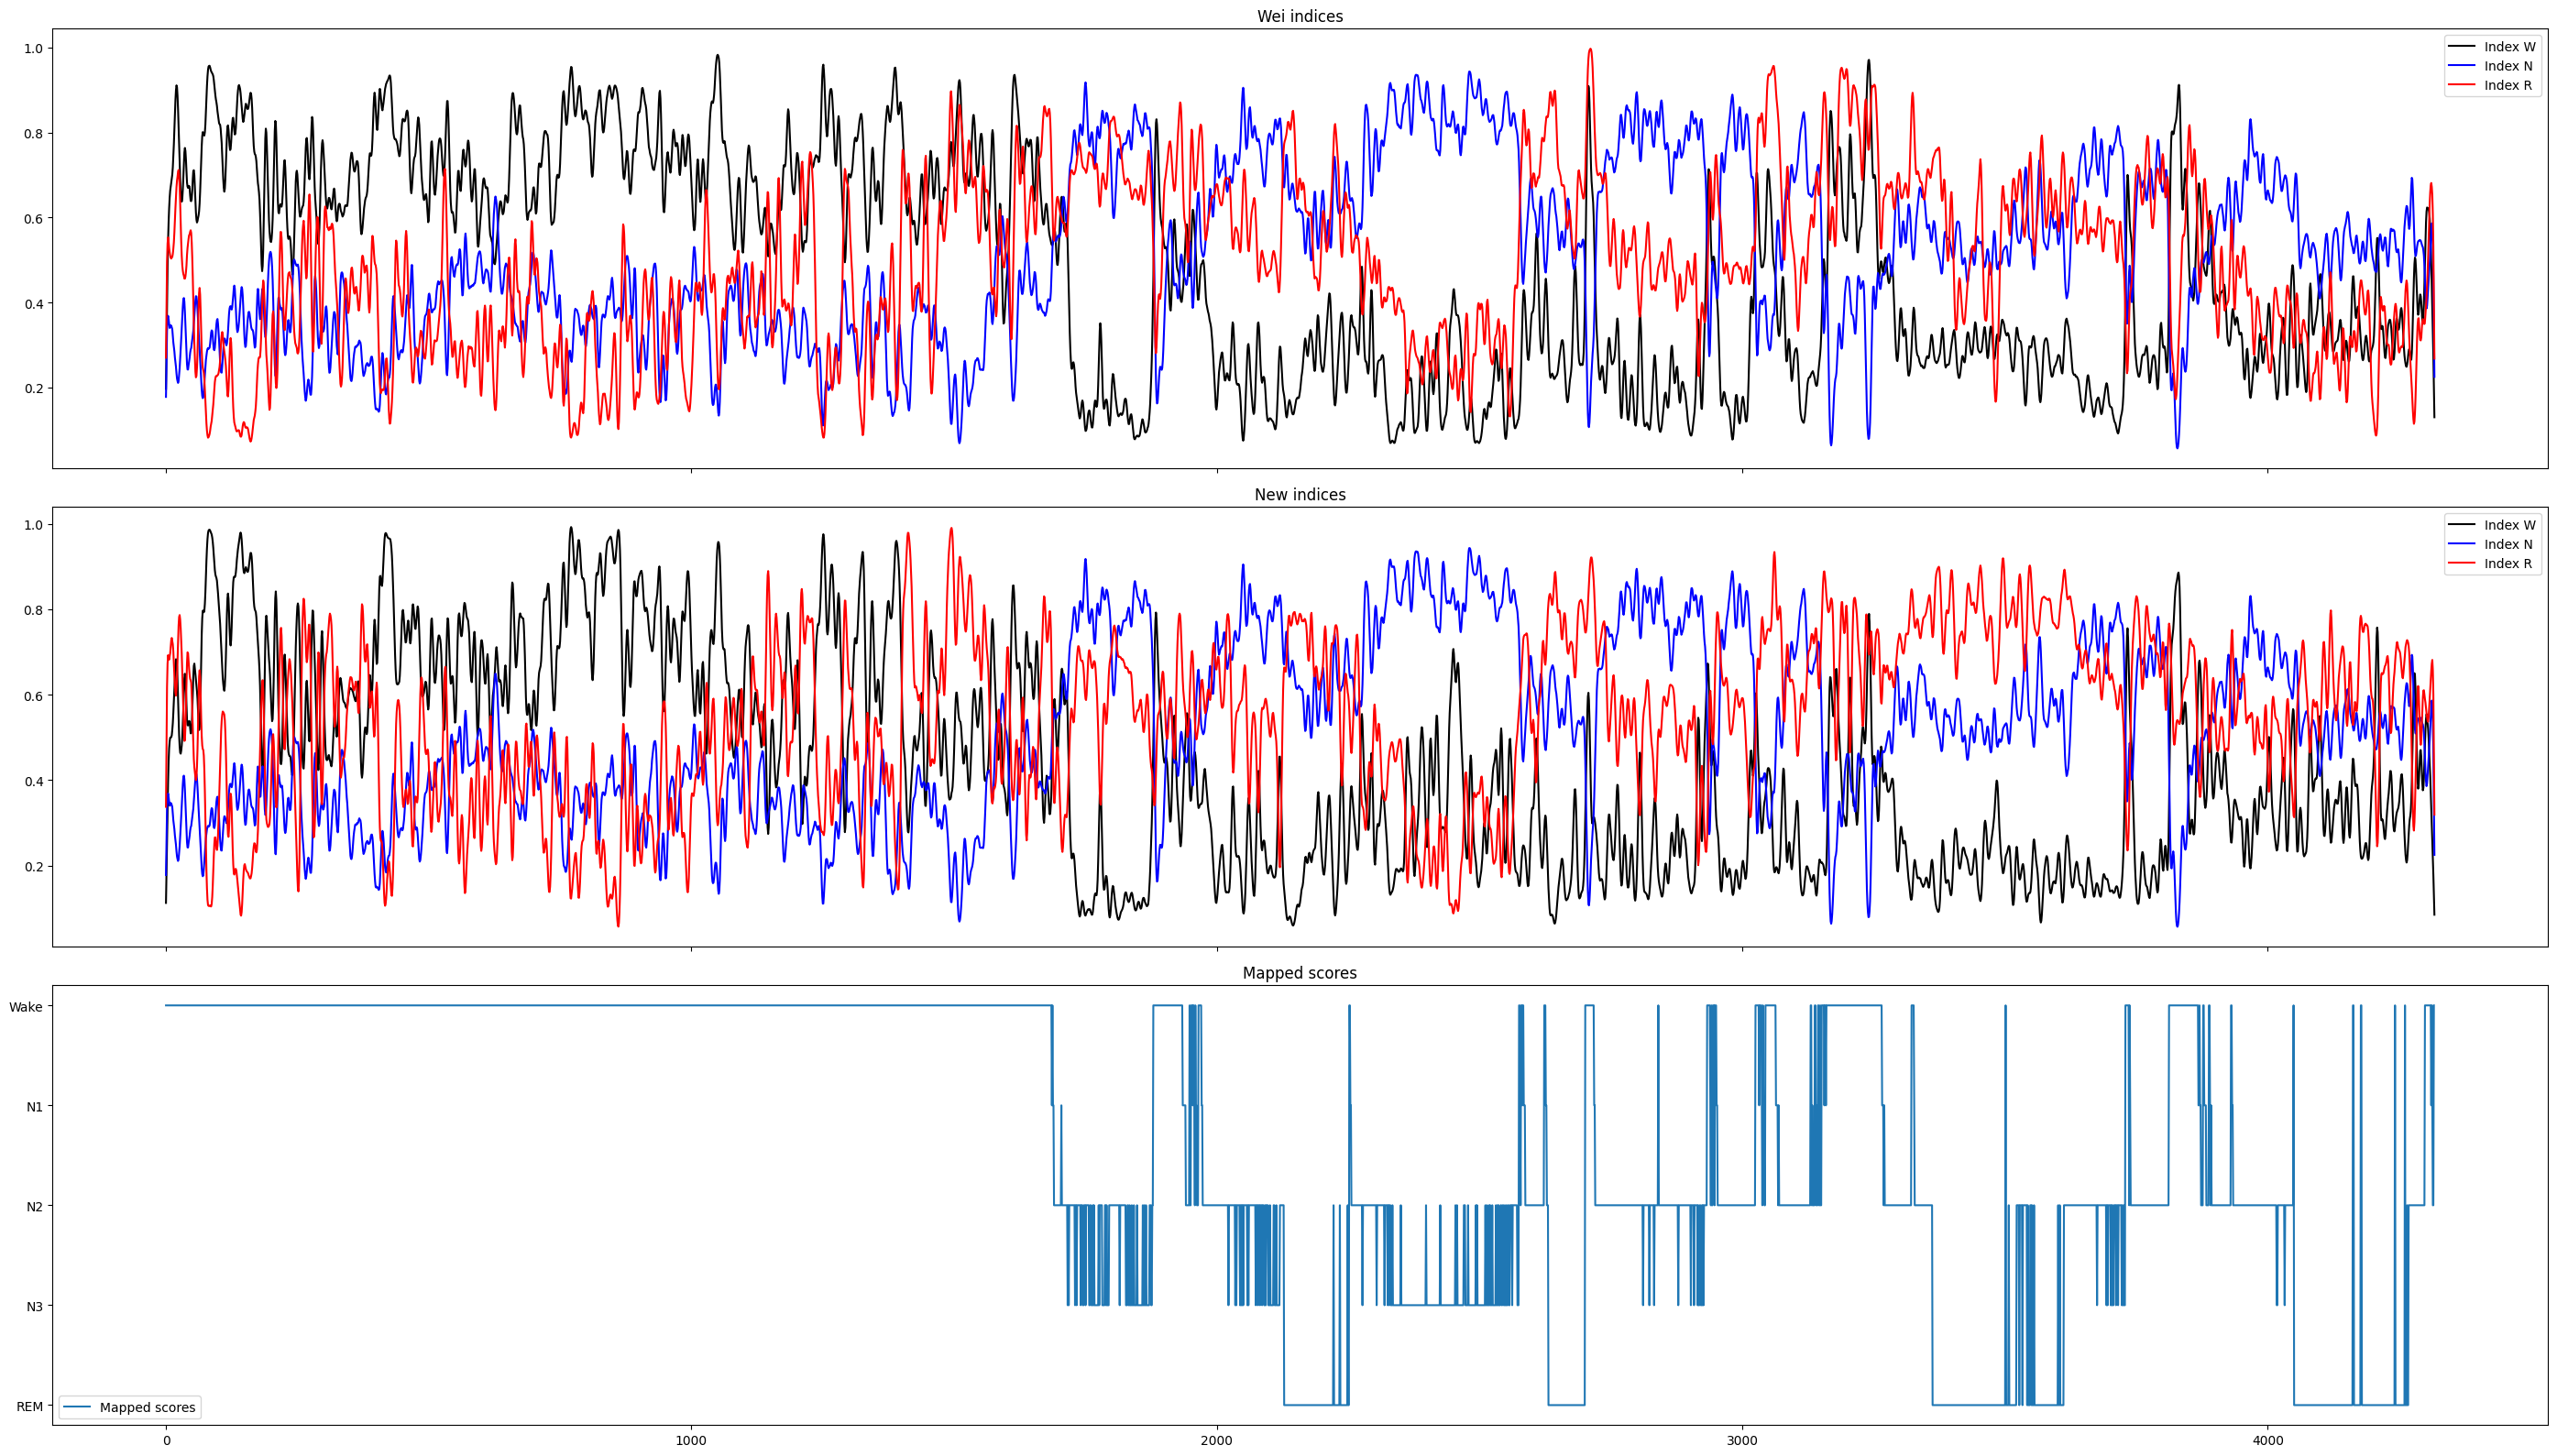

In [63]:
# All main indices
times = np.arange(0, len(epochs))
hypno_times = np.arange(0, len(hypno_epochs))
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize = (28, 16))

# Plot data on each subplot
ax1.plot(epochs[times], index_w_smoothed[times], label='Index W', color='black')
ax1.plot(epochs[times], index_n_smoothed[times], label='Index N', color='blue')
ax1.plot(epochs[times], index_r_smoothed[times], label='Index R', color='red')

ax2.plot(epochs[times], nindex_w_smoothed[times], label='Index W', color='black')
ax2.plot(epochs[times], index_n_smoothed[times], label='Index N', color='blue')
ax2.plot(epochs[times], nindex_r_smoothed[times], label='Index R', color='red')

ax3.plot(hypno_epochs[hypno_times], mapped_scores_old[hypno_times], label='Mapped scores')

# Add legends
ax1.legend()
ax2.legend()
ax3.legend()

# Add titles
ax1.set_title('Wei indices')
ax2.set_title('New indices')
ax3.set_title('Mapped scores')
ax3.set_yticks([0, 1, 2, 3, 4])
ax3.set_yticklabels(state_labels)
ax3.invert_yaxis()
# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig('all_new_indices_vs_wei.svg', format='svg')
# Show the plots
plt.show()

C:\Users\timmi\AppData\Local\Temp\ipykernel_13172\3434670807.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


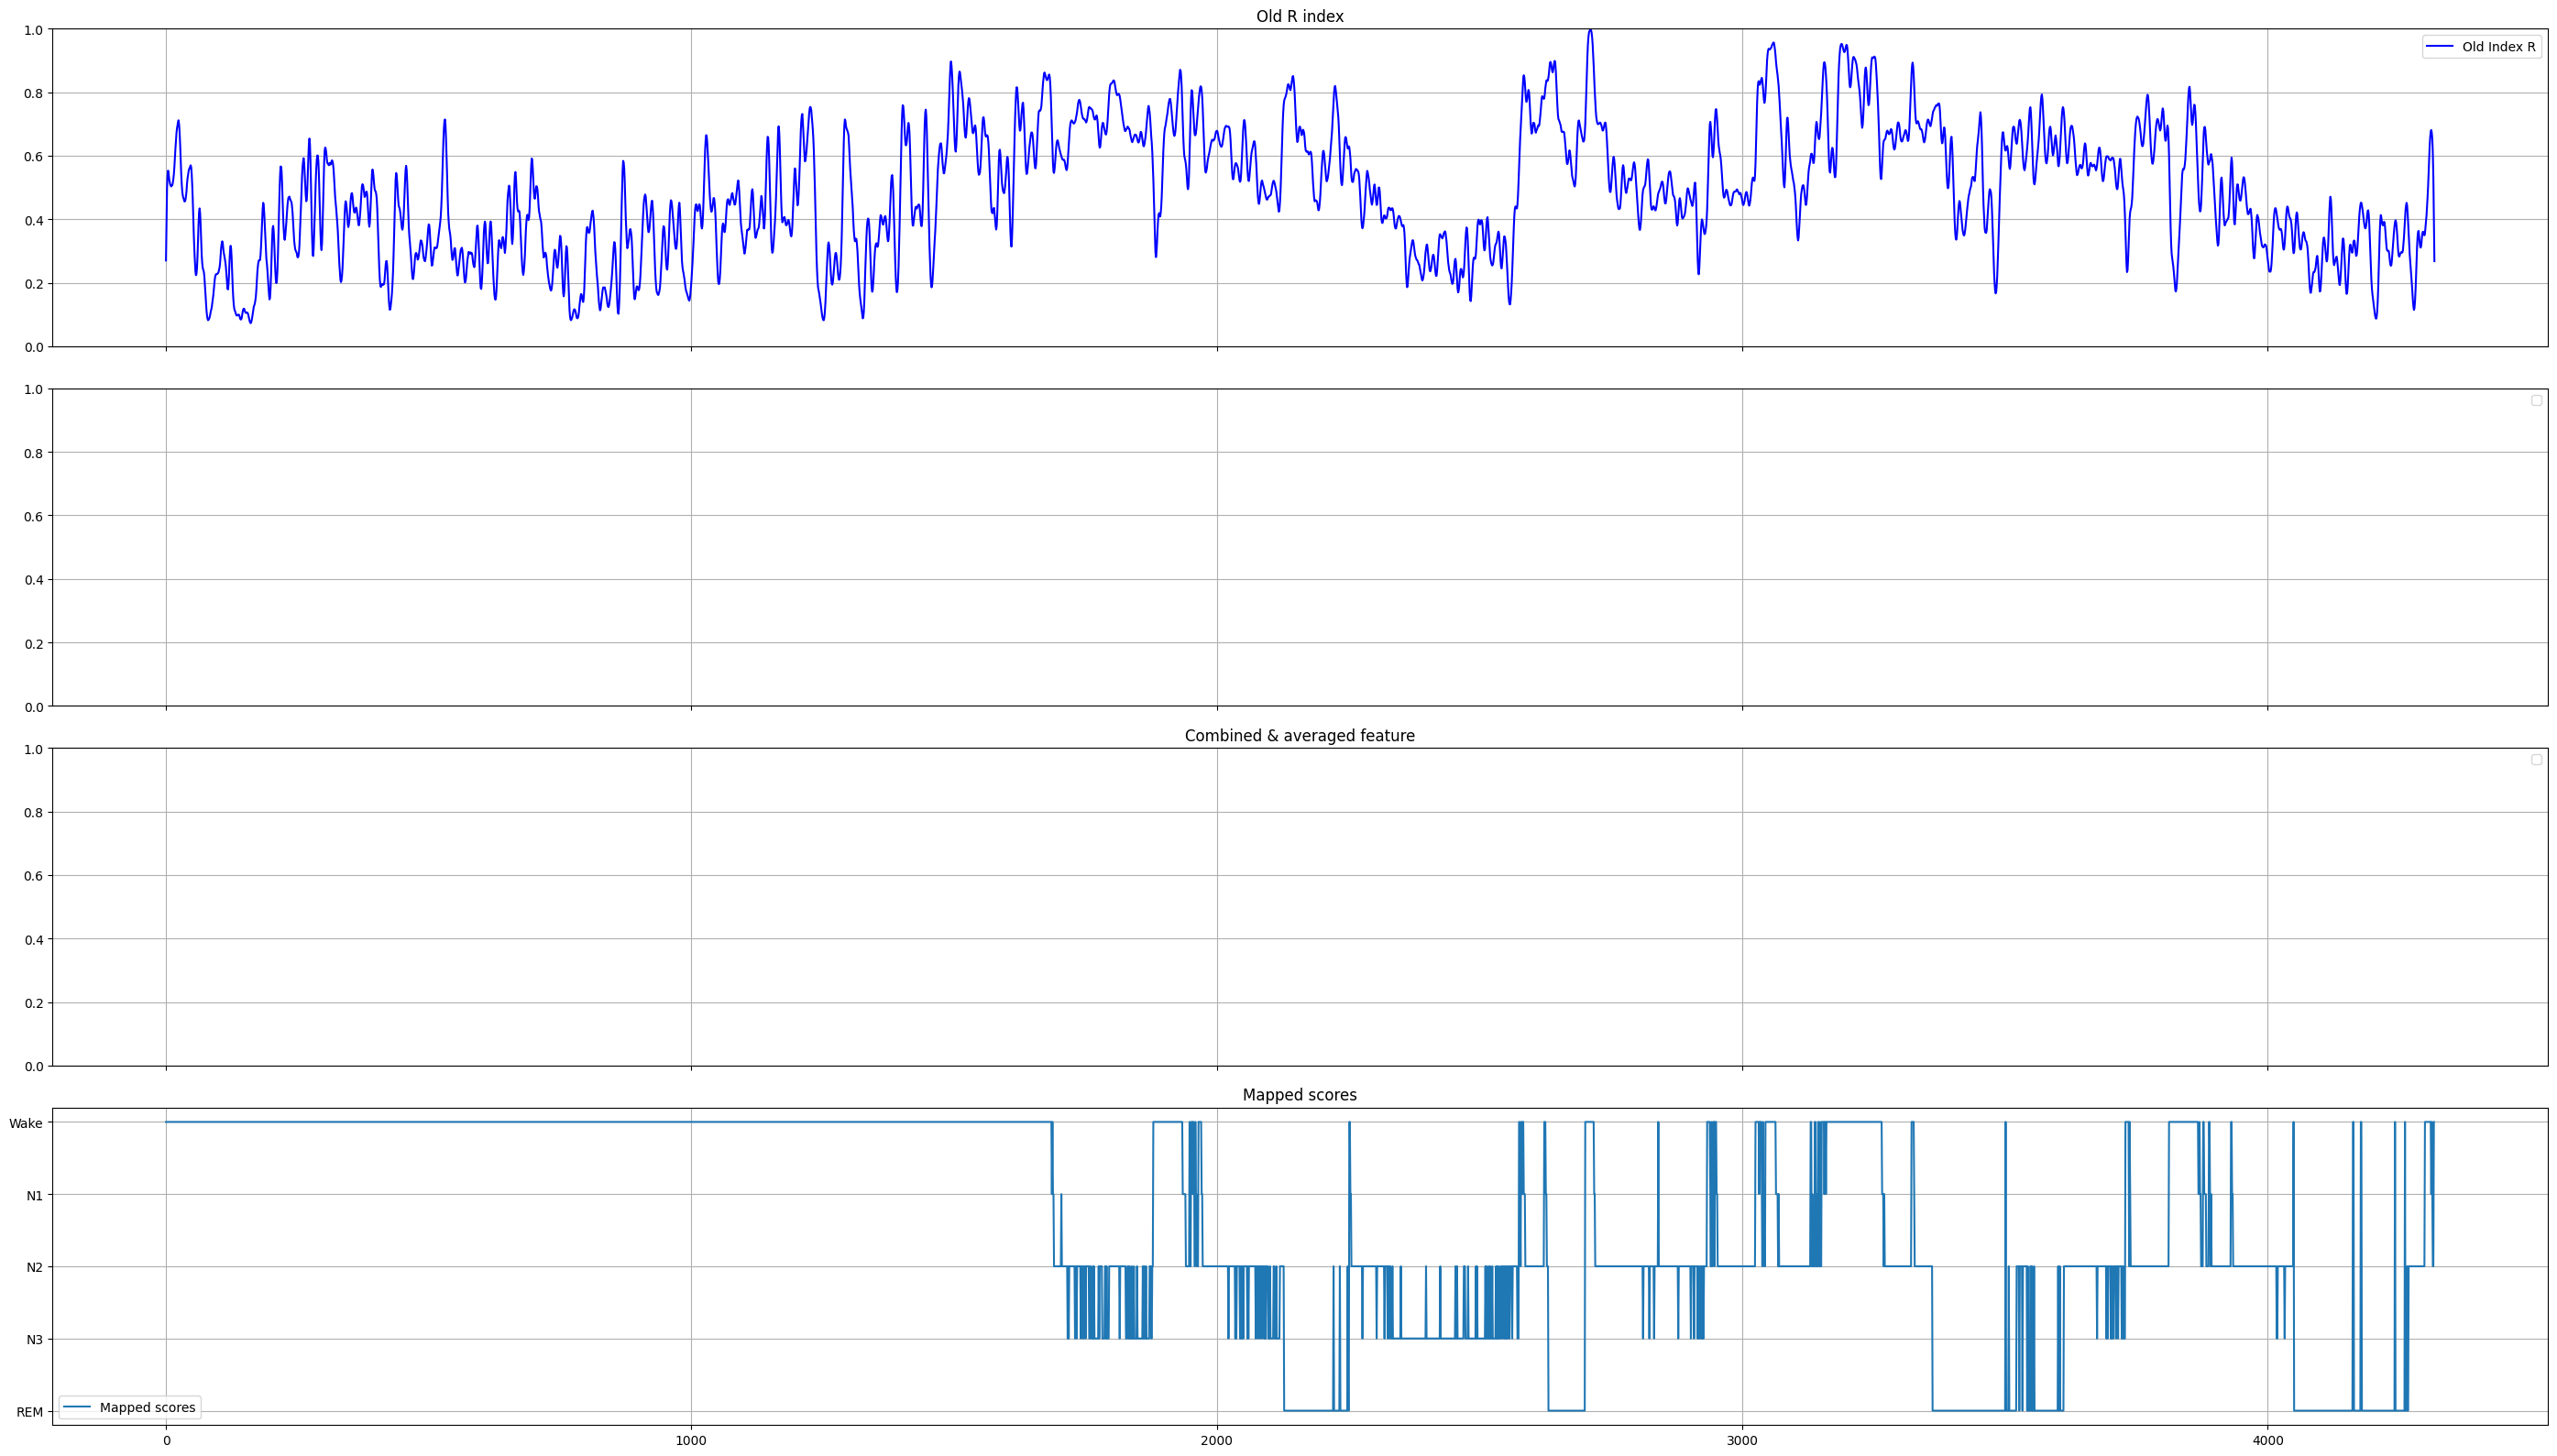

In [64]:

times = np.arange(0, len(epochs))
hypno_times = np.arange(0, len(hypno_epochs))
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, sharex=True, figsize = (28, 16))

# Plot data on each subplot
ax1.plot(epochs[times], index_r_smoothed[times], label='Old Index R', color='blue')

# ax2.plot(epochs[times], rem_features[times], label="EOG feature", color='orange')

# ax3.plot(epochs[times], nindex_r_smoothed_n[times], label='Combined & averaged index', color='black')

ax4.plot(hypno_epochs[hypno_times], mapped_scores_old[hypno_times], label='Mapped scores')

# Add legends
ax1.legend()
ax2.legend()
ax3.legend()
ax4.legend()

# Add titles
ax1.set_title('Old R index')
# ax2.set_title('EOG feature')
ax3.set_title('Combined & averaged feature')
ax4.set_title('Mapped scores')
ax1.set_ylim(0,1)
ax2.set_ylim(0,1)
ax3.set_ylim(0,1)
ax4.set_yticks([0, 1, 2, 3, 4])
ax4.set_yticklabels(state_labels)
ax4.invert_yaxis()
# Adjust layout to avoid overlap
ax1.grid(True)
ax2.grid(True)
ax3.grid(True)
ax4.grid(True)
plt.tight_layout()
plt.savefig('feature_comparison_rem.svg', format='svg')
# Show the plots
plt.show()

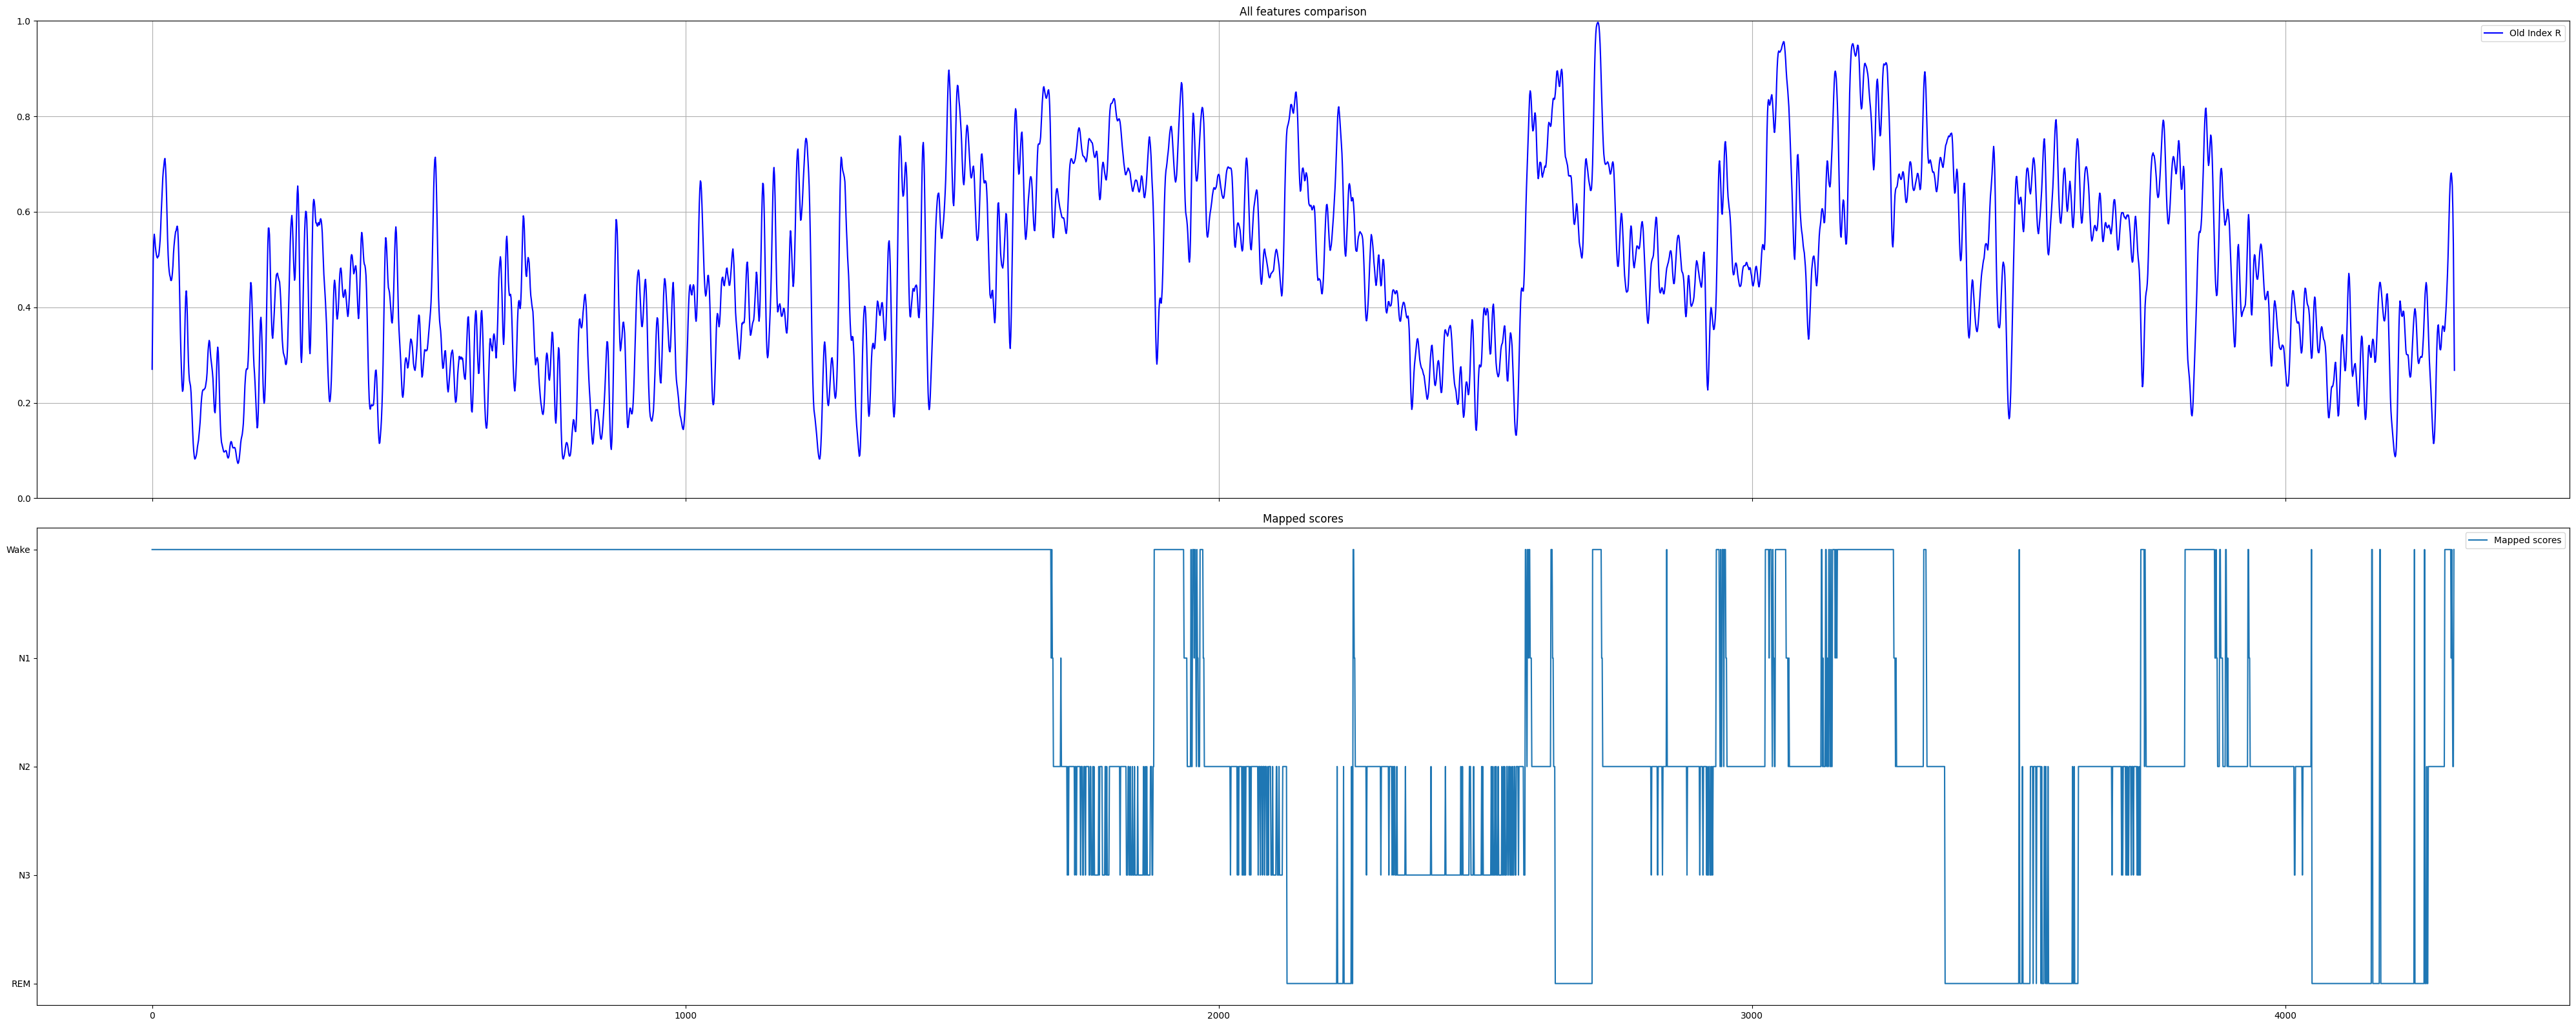

In [65]:

times = np.arange(0, len(epochs))
hypno_times = np.arange(0, len(hypno_epochs))
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize = (40, 16))

# Plot data on each subplot
ax1.plot(epochs[times], index_r_smoothed[times], label='Old Index R', color='blue')

# ax1.plot(epochs[times], rem_features[times], label="EOG feature", color='orange')

# ax1.plot(epochs[times], nindex_r_smoothed_n[times], label='Combined & averaged index', color='black')

ax2.plot(hypno_epochs[hypno_times], mapped_scores_old[hypno_times], label='Mapped scores')

# Add legends
ax1.legend()
ax2.legend()
ax1.set_ylim(0,1)
ax1.grid(True)

ax1.set_title('All features comparison')
ax2.set_title('Mapped scores')
ax2.set_yticks([0, 1, 2, 3, 4])
ax2.set_yticklabels(state_labels)
ax2.invert_yaxis()
# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig('feature_comparison_rem_1plot.svg', format='svg')
# Show the plots
plt.show()

###### Prerequisites

In [66]:
# Wei
index_Wake = [[],[],[]]
index_n1 = [[],[],[]]
index_n2 = [[],[],[]]
index_n3 = [[],[],[]]
index_REM = [[],[],[]]
for i, el in enumerate(mapped_scores):

  if el == 'Wake':
    index_Wake[0].append(index_w_smoothed[i])
    index_Wake[1].append(index_r_smoothed[i])
    index_Wake[2].append(index_n_smoothed[i])

  elif el == 'N1':
    index_n1[0].append(index_w_smoothed[i])
    index_n1[1].append(index_r_smoothed[i])
    index_n1[2].append(index_n_smoothed[i])
  elif el == 'N2':
    index_n2[0].append(index_w_smoothed[i])
    index_n2[1].append(index_r_smoothed[i])
    index_n2[2].append(index_n_smoothed[i])
  elif el == 'N3':
    index_n3[0].append(index_w_smoothed[i])
    index_n3[1].append(index_r_smoothed[i])
    index_n3[2].append(index_n_smoothed[i])
  elif el == 'REM':
    index_REM[0].append(index_w_smoothed[i])
    index_REM[1].append(index_r_smoothed[i])
    index_REM[2].append(index_n_smoothed[i])

# New
nindex_Wake = [[],[],[]]
nindex_n1 = [[],[],[]]
nindex_n2 = [[],[],[]]
nindex_n3 = [[],[],[]]
nindex_REM = [[],[],[]]
for i, el in enumerate(mapped_scores):

  if el == 'Wake':
    nindex_Wake[0].append(index_w_smoothed[i])
    nindex_Wake[1].append(index_r_smoothed[i])
    nindex_Wake[2].append(nindex_n_smoothed[i])

  elif el == 'N1':
    nindex_n1[0].append(index_w_smoothed[i])
    nindex_n1[1].append(index_r_smoothed[i])
    nindex_n1[2].append(nindex_n_smoothed[i])
  elif el == 'N2':
    nindex_n2[0].append(index_w_smoothed[i])
    nindex_n2[1].append(index_r_smoothed[i])
    nindex_n2[2].append(nindex_n_smoothed[i])
  elif el =='N3':
    nindex_n3[0].append(index_w_smoothed[i])
    nindex_n3[1].append(index_r_smoothed[i])
    nindex_n3[2].append(nindex_n_smoothed[i])
  elif el == 'REM':
    nindex_REM[0].append(index_w_smoothed[i])
    nindex_REM[1].append(index_r_smoothed[i])
    nindex_REM[2].append(nindex_n_smoothed[i])

In [67]:
# Wei
wake_w = np.average(index_Wake[0])
wake_r = np.average(index_Wake[1])
wake_n = np.average(index_Wake[2])
n1_w = np.average(index_n1[0])
n1_r = np.average(index_n1[1])
n1_n = np.average(index_n1[2])
n2_w = np.average(index_n2[0])
n2_r = np.average(index_n2[1])
n2_n = np.average(index_n2[2])
n3_w = np.average(index_n3[0])
n3_r = np.average(index_n3[1])
n3_n = np.average(index_n3[2])
REM_w = np.average(index_REM[0])
REM_r = np.average(index_REM[1])
REM_n = np.average(index_REM[2])

# New
nwake_w = np.average(nindex_Wake[0])
nwake_r = np.average(nindex_Wake[1])
nwake_n = np.average(nindex_Wake[2])
nn1_w = np.average(nindex_n1[0])
nn1_r = np.average(nindex_n1[1])
nn1_n = np.average(nindex_n1[2])
nn2_w = np.average(nindex_n2[0])
nn2_r = np.average(nindex_n2[1])
nn2_n = np.average(nindex_n2[2])
nn3_w = np.average(nindex_n3[0])
nn3_r = np.average(nindex_n3[1])
nn3_n = np.average(nindex_n3[2])
nREM_w = np.average(nindex_REM[0])
nREM_r = np.average(nindex_REM[1])
nREM_n = np.average(nindex_REM[2])

###### Barplots

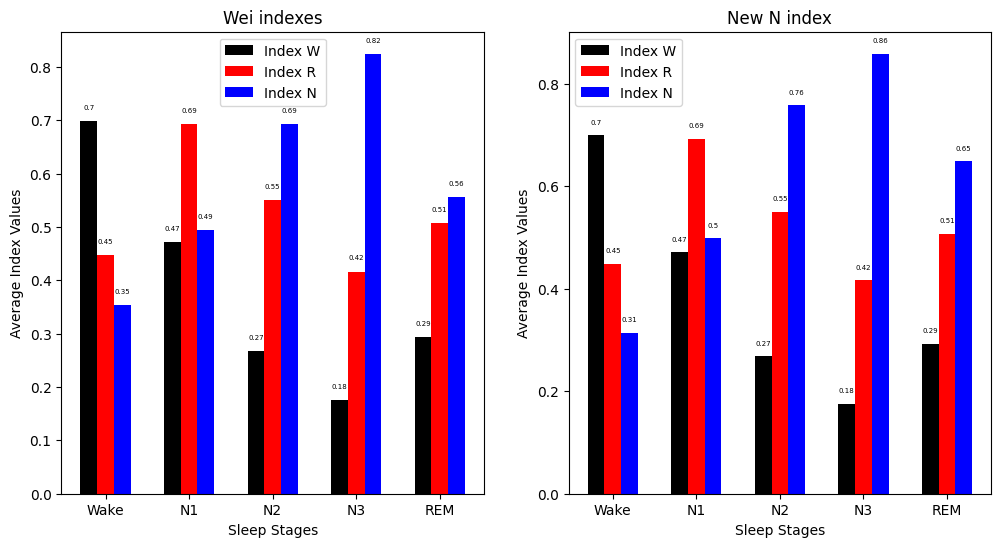

In [68]:
plt.figure(figsize=(12, 6))

# Wei indexes
plt.subplot(1, 2, 1)
categories = ['Wake', 'N1', 'N2','N3', 'REM']
index_types = ['Index_w', 'Index_r', 'Index_n']
values_wake = [wake_w, n1_w, n2_w, n3_w, REM_w]
values_REM = [wake_r, n1_r, n2_r, n3_r, REM_r]
values_NREM = [wake_n, n1_n, n2_n, n3_n, REM_n]
x = np.arange(len(categories))
bar_width = 0.2
# Create bar plots
plt.bar(x - bar_width, values_wake, width=bar_width, label='Index W', color = 'black')
plt.bar(x, values_REM, width=bar_width, label='Index R', color = 'red',)
plt.bar(x + bar_width, values_NREM, width=bar_width, label='Index N', color = 'blue')
# Add labels and title
plt.xlabel('Sleep Stages')
plt.ylabel('Average Index Values')
plt.title('Wei indexes')
plt.xticks(x, categories)
plt.legend()
fontsize = 5
for i in range(len(categories)):
    plt.text(x[i] - bar_width, values_wake[i] + 0.02, str(round(values_wake[i], 2)), ha='center', va='bottom', fontsize=fontsize)
    plt.text(x[i], values_REM[i] + 0.02, str(round(values_REM[i], 2)), ha='center', va='bottom', fontsize=fontsize)
    plt.text(x[i] + bar_width, values_NREM[i] + 0.02, str(round(values_NREM[i], 2)), ha='center', va='bottom', fontsize=fontsize)

# New W index
plt.subplot(1, 2, 2)
categories = ['Wake', 'N1', 'N2','N3', 'REM']
index_types = ['Index_w', 'Index_r', 'Index_n']
values_wake = [nwake_w, nn1_w, nn2_w, nn3_w, REM_w]
values_REM = [nwake_r, nn1_r, nn2_r, nn3_r, nREM_r]
values_NREM = [nwake_n, nn1_n, nn2_n, nn3_n, nREM_n]
x = np.arange(len(categories))
bar_width = 0.2
# Create bar plots
plt.bar(x - bar_width, values_wake, width=bar_width, label='Index W', color = 'black')
plt.bar(x, values_REM, width=bar_width, label='Index R', color = 'red')
plt.bar(x + bar_width, values_NREM, width=bar_width, label='Index N', color = 'blue')
# Add labels and title
plt.xlabel('Sleep Stages')
plt.ylabel('Average Index Values')
plt.title('New N index')
plt.xticks(x, categories)
plt.legend()

for i in range(len(categories)):
    plt.text(x[i] - bar_width, values_wake[i] + 0.02, str(round(values_wake[i], 2)), ha='center', va='bottom', fontsize=fontsize)
    plt.text(x[i], values_REM[i] + 0.02, str(round(values_REM[i], 2)), ha='center', va='bottom', fontsize=fontsize)
    plt.text(x[i] + bar_width, values_NREM[i] + 0.02, str(round(values_NREM[i], 2)), ha='center', va='bottom', fontsize=fontsize)

plt.savefig("wei_vs_new_n_barplot.svg", format='svg')

### Comparing Wei vs New

#### Plot

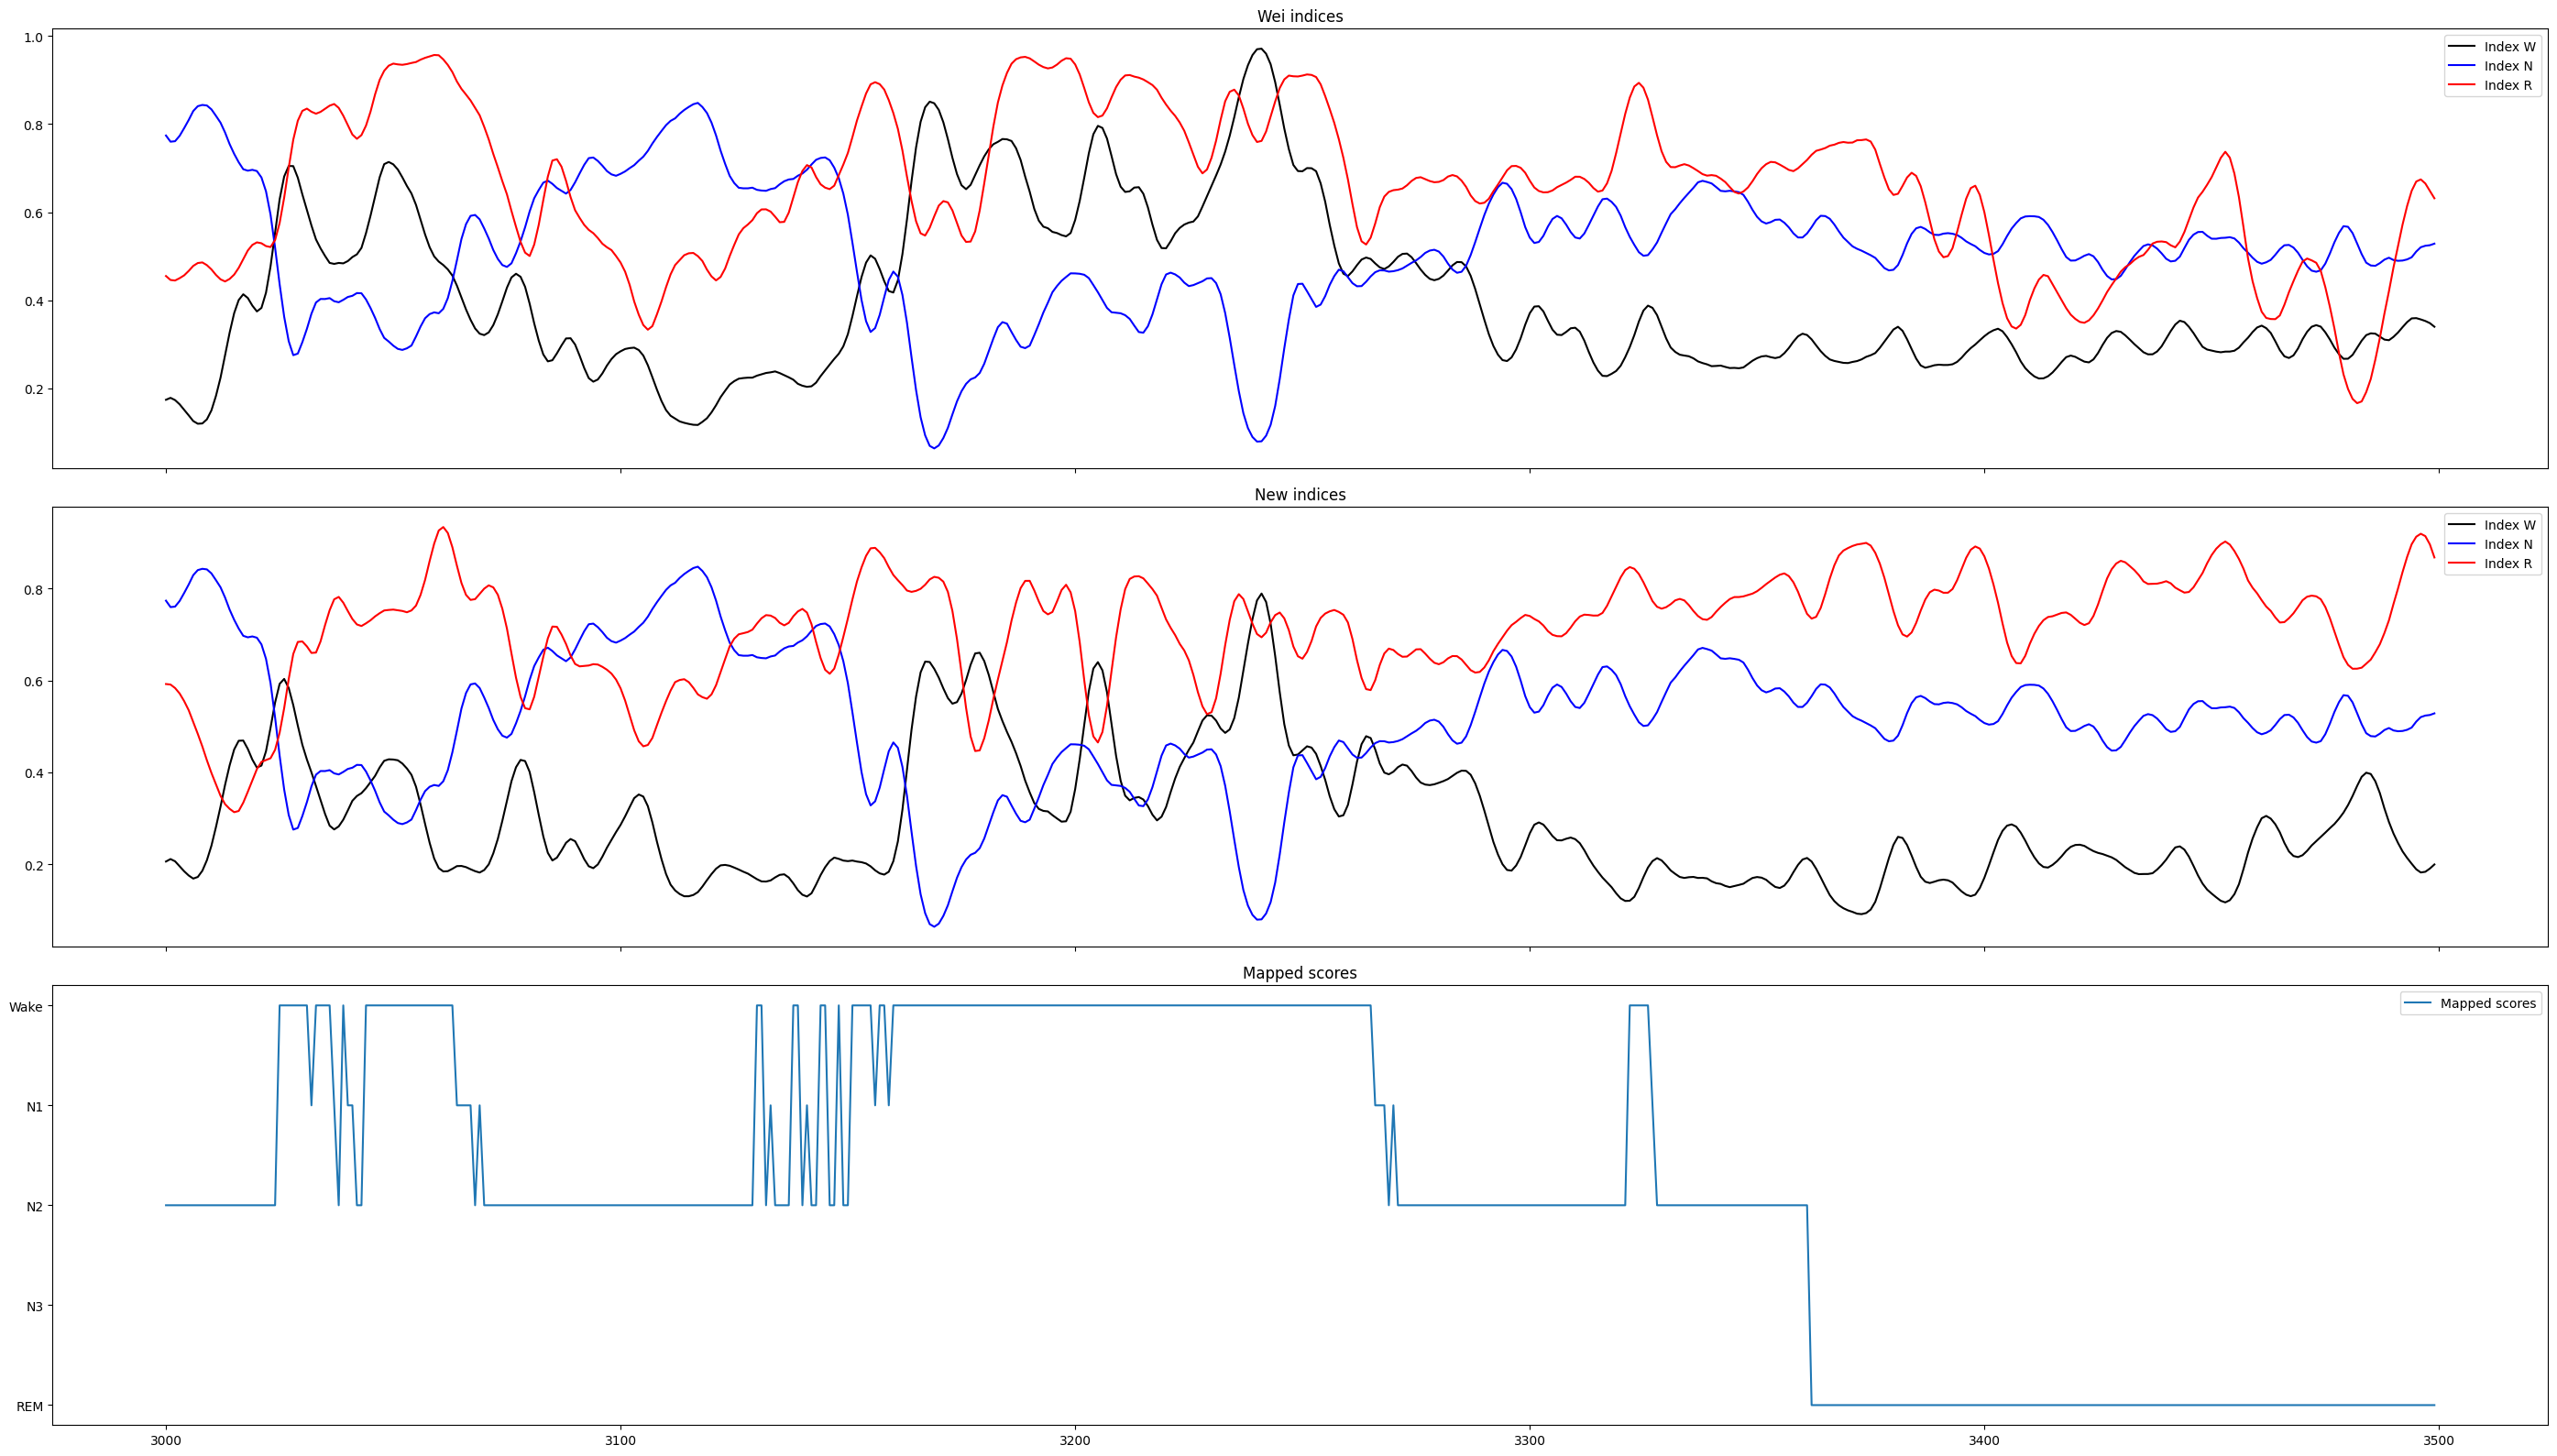

In [69]:
# All main indices
times = np.arange(3000, 3500)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize = (28, 16))

# Plot data on each subplot
ax1.plot(epochs[times], index_w_smoothed[times], label='Index W', color='black')
ax1.plot(epochs[times], index_n_smoothed[times], label='Index N', color='blue')
ax1.plot(epochs[times], index_r_smoothed[times], label='Index R', color='red')

ax2.plot(epochs[times], nindex_w_smoothed[times], label='Index W', color='black')
ax2.plot(epochs[times], index_n_smoothed[times], label='Index N', color='blue')
ax2.plot(epochs[times], nindex_r_smoothed[times], label='Index R', color='red')

ax3.plot(hypno_epochs[times], mapped_scores_old[times], label='Mapped scores')

# Add legends
ax1.legend()
ax2.legend()
ax3.legend()

# Add titles
ax1.set_title('Wei indices')
ax2.set_title('New indices')
ax3.set_title('Mapped scores')
ax3.set_yticks([0, 1, 2, 3, 4])
ax3.set_yticklabels(state_labels)
ax3.invert_yaxis()
# Adjust layout to avoid overlap
plt.tight_layout()
# Show the plots
plt.savefig("all_new_indices_vs_wei_closeup.svg", format='svg', dpi=300)
plt.show()

###### Prerequisites

In [70]:
# Wei
index_Wake = [[],[],[]]
index_n1 = [[],[],[]]
index_n2 = [[],[],[]]
index_n3 = [[],[],[]]
index_REM = [[],[],[]]
for i, el in enumerate(mapped_scores):

  if el == 'Wake':
    index_Wake[0].append(index_w_smoothed[i])
    index_Wake[1].append(index_r_smoothed[i])
    index_Wake[2].append(index_n_smoothed[i])

  elif el == 'N1':
    index_n1[0].append(index_w_smoothed[i])
    index_n1[1].append(index_r_smoothed[i])
    index_n1[2].append(index_n_smoothed[i])
  elif el == 'N2':
    index_n2[0].append(index_w_smoothed[i])
    index_n2[1].append(index_r_smoothed[i])
    index_n2[2].append(index_n_smoothed[i])
  elif el == 'N3':
    index_n3[0].append(index_w_smoothed[i])
    index_n3[1].append(index_r_smoothed[i])
    index_n3[2].append(index_n_smoothed[i])
  elif el == 'REM':
    index_REM[0].append(index_w_smoothed[i])
    index_REM[1].append(index_r_smoothed[i])
    index_REM[2].append(index_n_smoothed[i])

# New
nindex_Wake = [[],[],[]]
nindex_n1 = [[],[],[]]
nindex_n2 = [[],[],[]]
nindex_n3  = [[],[],[]]
nindex_REM = [[],[],[]]
for i, el in enumerate(mapped_scores):

  if el == 'Wake':
    nindex_Wake[0].append(nindex_w_smoothed[i])
    nindex_Wake[1].append(nindex_r_smoothed[i])
    nindex_Wake[2].append(index_n_smoothed[i])

  elif el == 'N1':
    nindex_n1[0].append(nindex_w_smoothed[i])
    nindex_n1[1].append(nindex_r_smoothed[i])
    nindex_n1[2].append(index_n_smoothed[i])
  elif el == 'N2':
    nindex_n2[0].append(nindex_w_smoothed[i])
    nindex_n2[1].append(nindex_r_smoothed[i])
    nindex_n2[2].append(index_n_smoothed[i])
  elif el == 'N3':
    nindex_n3[0].append(nindex_w_smoothed[i])
    nindex_n3[1].append(nindex_r_smoothed[i])
    nindex_n3[2].append(index_n_smoothed[i])
  elif el == 'REM':
    nindex_REM[0].append(nindex_w_smoothed[i])
    nindex_REM[1].append(nindex_r_smoothed[i])
    nindex_REM[2].append(index_n_smoothed[i])

In [71]:
# Wei
wake_w = np.average(index_Wake[0])
wake_r = np.average(index_Wake[1])
wake_n = np.average(index_Wake[2])
n1_w = np.average(index_n1[0])
n1_r = np.average(index_n1[1])
n1_n = np.average(index_n1[2])
n2_w = np.average(index_n2[0])
n2_r = np.average(index_n2[1])
n2_n = np.average(index_n2[2])
n3_w = np.average(index_n3[0])
n3_r = np.average(index_n3[1])
n3_n = np.average(index_n3[2])
REM_w = np.average(index_REM[0])
REM_r = np.average(index_REM[1])
REM_n = np.average(index_REM[2])

# New
nwake_w = np.average(nindex_Wake[0])
nwake_r = np.average(nindex_Wake[1])
nwake_n = np.average(nindex_Wake[2])
nn1_w = np.average(nindex_n1[0])
nn1_r = np.average(nindex_n1[1])
nn1_n = np.average(nindex_n1[2])
nn2_w = np.average(nindex_n2[0])
nn2_r = np.average(nindex_n2[1])
nn2_n = np.average(nindex_n2[2])
nn3_w = np.average(nindex_n3[0])
nn3_r = np.average(nindex_n3[1])
nn3_n = np.average(nindex_n3[2])
nREM_w = np.average(nindex_REM[0])
nREM_r = np.average(nindex_REM[1])
nREM_n = np.average(nindex_REM[2])

In [72]:
if 'Wake' not in mapped_scores:
  nwake_w = 0
  nwake_r = 0
  nwake_n = 0
if 'REM' not in mapped_scores:
  nREM_w = 0
  nREM_r = 0
  nREM_n = 0
if 'N1' not in mapped_scores:
  nNREM_w = 0
  nNREM_r = 0
  nNREM_n = 0
if 'N2' not in mapped_scores:
  nNREM_w = 0
  nNREM_r = 0
  nNREM_n = 0
if 'N3' not in mapped_scores:
  nNREM_w = 0
  nNREM_r = 0
  nNREM_n = 0

#### Barplots

###### Barplots

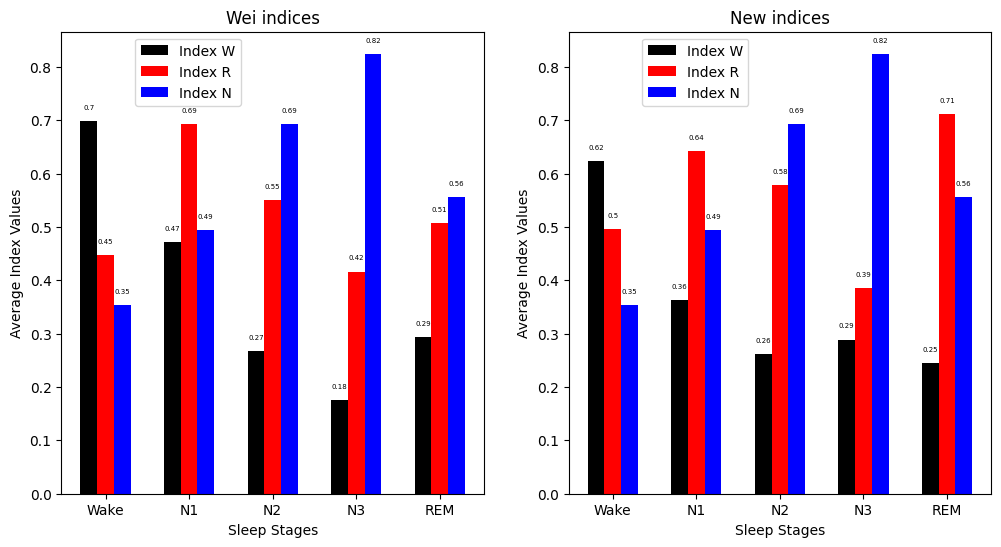

In [73]:
plt.figure(figsize=(12, 6))

# Wei indexes
plt.subplot(1, 2, 1)
categories = ['Wake', 'N1', 'N2','N3', 'REM']
index_types = ['Index_w', 'Index_r', 'Index_n']
values_wake = [wake_w, n1_w, n2_w, n3_w, REM_w]
values_REM = [wake_r, n1_r, n2_r, n3_r, REM_r]
values_NREM = [wake_n, n1_n, n2_n, n3_n, REM_n]
x = np.arange(len(categories))
bar_width = 0.2
# Create bar plots
plt.bar(x - bar_width, values_wake, width=bar_width, label='Index W', color = 'black')
plt.bar(x, values_REM, width=bar_width, label='Index R', color = 'red',)
plt.bar(x + bar_width, values_NREM, width=bar_width, label='Index N', color = 'blue')
# Add labels and title
plt.xlabel('Sleep Stages')
plt.ylabel('Average Index Values')
plt.title('Wei indices')
plt.xticks(x, categories)
plt.legend(loc='upper center', bbox_to_anchor=(0.3, 1))

for i in range(len(categories)):
    plt.text(x[i] - bar_width, values_wake[i] + 0.02, str(round(values_wake[i], 2)), ha='center', va='bottom', fontsize=fontsize)
    plt.text(x[i], values_REM[i] + 0.02, str(round(values_REM[i], 2)), ha='center', va='bottom', fontsize=fontsize)
    plt.text(x[i] + bar_width, values_NREM[i] + 0.02, str(round(values_NREM[i], 2)), ha='center', va='bottom', fontsize=fontsize)




# New W index
plt.subplot(1, 2, 2)
categories = ['Wake', 'N1', 'N2','N3', 'REM']
index_types = ['Index_w', 'Index_r', 'Index_n']
values_wake = [nwake_w, nn1_w, nn2_w, nn3_w, nREM_w]
values_REM = [nwake_r, nn1_r, nn2_r, nn3_r, nREM_r]
values_NREM = [nwake_n, nn1_n, nn2_n, nn3_n, nREM_n]
x = np.arange(len(categories))
bar_width = 0.2
# Create bar plots
plt.bar(x - bar_width, values_wake, width=bar_width, label='Index W', color = 'black')
plt.bar(x, values_REM, width=bar_width, label='Index R', color = 'red',)
plt.bar(x + bar_width, values_NREM, width=bar_width, label='Index N', color = 'blue')
# Add labels and title
plt.xlabel('Sleep Stages')
plt.ylabel('Average Index Values')
plt.title('New indices')
plt.xticks(x, categories)
plt.legend(loc='upper center', bbox_to_anchor=(0.3, 1))

for i in range(len(categories)):
    plt.text(x[i] - bar_width, values_wake[i] + 0.02, str(round(values_wake[i], 2)), ha='center', va='bottom', fontsize=fontsize)
    plt.text(x[i], values_REM[i] + 0.02, str(round(values_REM[i], 2)), ha='center', va='bottom', fontsize=fontsize)
    plt.text(x[i] + bar_width, values_NREM[i] + 0.02, str(round(values_NREM[i], 2)), ha='center', va='bottom', fontsize=fontsize)
plt.savefig('all_new_indices_vs_wei_barplot.svg', format='svg')
plt.show()

# 3D temporal visualisation of index evolution

In [74]:
import plotly.express as px
import pandas as pd

df = pd.DataFrame({
    'summed_emg': savgol_filter(EMG_norm, window_length=101, polyorder=4)[0:1000],               # you want to choose a time interval where you can see a whole wake-nrem-rem-nrem cycle
    'normalized_delta_power': savgol_filter(delta_norm, window_length=101, polyorder=4)[0:1000],  # extra smoothing so that we can actullay see something
    'normalized_theta_power': savgol_filter(theta_norm, window_length=101, polyorder=4)[0:1000]
})

fig = px.scatter_3d(df, x='normalized_theta_power', y='normalized_delta_power', z='summed_emg',
                    title='',
                    color=df.index,
                    color_continuous_scale='Magma',
                    opacity=0.8)

fig.update_layout(width=1000, height=900)
fig.show()

PCA data points:(4317, 3)


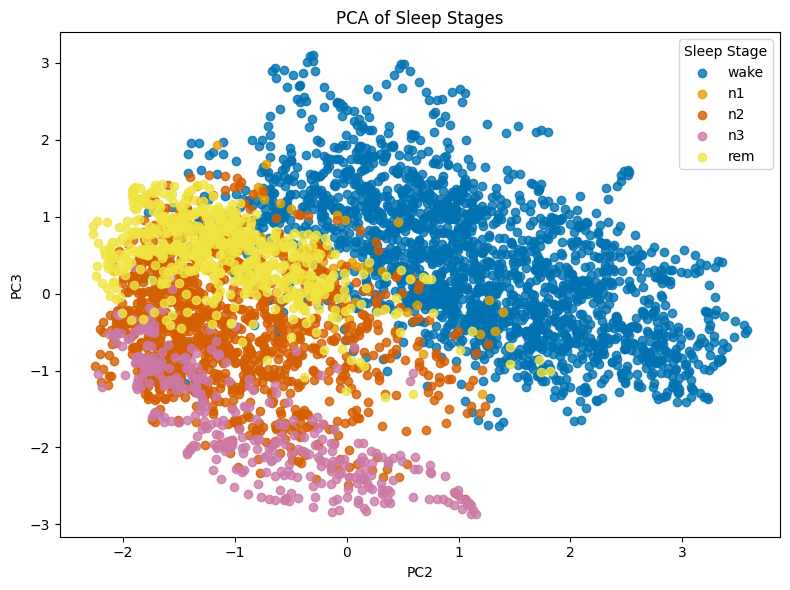

In [75]:
# mapped_scores_old = np.append(mapped_scores_old, [0,0])
arrays = [
    nindex_w_smoothed[:-1],
    index_n_smoothed[:-1],
    nindex_r_smoothed[:-1],
    mapped_scores_old
]
# print(f'epochs: {X.shape}')   # rows = number of samples (dots), columns = features
stage_map = {
    0.0: "wake",
    1.0: "n1",
    2.0: "n2",
    3.0: "n3",
    4.0: "rem"
}
array = np.column_stack(arrays)
df = pd.DataFrame(array)

x = df[[0, 1, 2]]
y = df[3]

scaler = StandardScaler()
X = x.to_numpy().astype(float)

# Replace NaNs with 0 (or another strategy like forward-fill)
X = np.nan_to_num(X, nan=0.0)
X_scaled = scaler.fit_transform(X)


pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)
print(f'PCA data points:{X_pca.shape}')
# Colorblind-friendly palette
colors = ['#0072B2', '#E69F00', '#D55E00', '#CC79A7', '#F0E442']

plt.figure(figsize=(8,6))
for i, label in enumerate(np.unique(y)):
    stage_name = stage_map.get(label, str(label))  # fallback in case of unexpected value
    plt.scatter(
        X_pca[y==label, 0],
        X_pca[y==label, 1],
        label=stage_name,
        color=colors[i % len(colors)],
        alpha=0.8
    )

plt.xlabel("PC2")
plt.ylabel("PC3")
plt.title("PCA of Sleep Stages")
plt.legend(title="Sleep Stage")
plt.tight_layout()
plt.savefig("Index_PCA_subject_2.svg", format='svg')
plt.show()